<a href="https://colab.research.google.com/github/pachterlab/varseek-examples/blob/main/vk_denovo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [vk denovo](https://github.com/pachterlab/varseek) demonstration
Call de novo variants from scRNA-seq reads, build a varseek reference from those variants, and count variant-supporting reads with vk count. This notebook uses a [10x PBMC 1k dataset](https://www.10xgenomics.com/datasets/1-k-pbm-cs-from-a-healthy-donor-v-3-chemistry-3-standard-3-0-0) as an example.

Written by Joseph Rich.
___


### Install varseek, and import all packages

In [1]:
try:
    import varseek as vk
except ImportError:
    print("varseek not found, installing...")
    !pip install -U -q varseek

In [2]:
import os
import re
import anndata as ad
import pandas as pd
import pysam

import varseek as vk

In [3]:
# !pip install -q ipython-autotime
%load_ext autotime

time: 70.1 μs (started: 2026-06-15 08:18:13 -07:00)


### Define important paths

In [4]:
# input files
fastqs_dir = os.path.join("data", "pbmc_1k_v3_fastqs")
technology = "10xv3"
reference_dir = os.path.join("data", "reference")
sequences = os.path.join(reference_dir, "Homo_sapiens.GRCh38.dna.primary_assembly.fa")
gtf = os.path.join(reference_dir, "Homo_sapiens.GRCh38.114.gtf")

# vk denovo out
variants_dir = os.path.join("data", "pbmc_1k_v3_variants")
variants_vcf = os.path.join(variants_dir, "variants.vcf.gz")
variants = os.path.join(variants_dir, "variants.tsv")
denovo_bam_dir = os.path.join(variants_dir, "bams")
star_genome_index_dir = os.path.join(reference_dir, "star_index")
denovo_star_alignment_dir = os.path.join(variants_dir, "star_alignments")

# vk ref out
vk_ref_out_dir = os.path.join("data", "varseek_ref_out_pbmc_1k_v3")
vcrs_index = os.path.join(vk_ref_out_dir, "vcrs_index_denovo.idx")
vcrs_t2g = os.path.join(vk_ref_out_dir, "vcrs_t2g_denovo.txt")

# vk count out
vk_count_out_dir = os.path.join("data", "varseek_count_out_pbmc_1k_v3")
vk_count_variants_vcf = os.path.join(vk_count_out_dir, "varseek_variants.vcf")

# general parameters
w = 37
k = 41
min_counts_denovo = 3
threads = 16
min_counts_clean = 1

time: 38.7 ms (started: 2026-06-15 08:18:13 -07:00)


### Download the PBMC fastq dataset

In [5]:
if not os.path.exists(fastqs_dir) or len(os.listdir(fastqs_dir)) == 0:
    !mkdir -p data && \
        cd data && \
        curl -O https://cf.10xgenomics.com/samples/cell-exp/3.0.0/pbmc_1k_v3/pbmc_1k_v3_fastqs.tar && \
        tar -xvf pbmc_1k_v3_fastqs.tar && \
        rm pbmc_1k_v3_fastqs.tar

time: 14.1 ms (started: 2026-06-12 12:24:57 -07:00)


### Download the reference genome (GRCh38, Ensembl 114, cDNA file)

In [29]:
if not os.path.exists(sequences):
    !gget ref -w dna -r 114 --out_dir {reference_dir} -d human
    !gunzip {sequences}.gz

if not os.path.exists(gtf):
    !gget ref -w gtf -r 114 --out_dir {reference_dir} -d human
    !gunzip {gtf}.gz

time: 15.1 ms (started: 2026-06-11 16:43:22 -07:00)


### Run varseek denovo

In [30]:
fastq_r2_files = sorted(
    os.path.join(root, file)
    for root, _, files in os.walk(fastqs_dir)
    for file in files
    if file.endswith((".fastq.gz", ".fq.gz", ".fastq", ".fq")) and "_R2_" in file
)

if not os.path.exists(variants):
    vk.denovo(
        inputs=fastq_r2_files,
        fasta_ref=sequences,
        gtf=gtf,
        aligner="STAR",
        star_genome_index_dir=star_genome_index_dir,
        star_alignment_prefix=f"{denovo_star_alignment_dir}/star_",
        out_bam_dir=denovo_bam_dir,
        output=variants_vcf,
        output_tsv=variants,
        min_counts=min_counts_denovo,
        threads=threads,
        read_length=91,
        verbose=1,
    )


variants_df = pd.read_csv(variants, sep="\t")
print(f"Number of variants: {len(variants_df)}")
variants_df.head()

Number of variants: 325583


/home/jrich/tmp/ipykernel_2038839/3070598833.py:26: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  variants_df = pd.read_csv(variants, sep="\t")


,seq_id,variant
0,1,g.199391G>A
1,1,g.511638T>C
2,1,g.511644T>C
3,1,g.511685T>C
4,1,g.511693T>C


time: 159 ms (started: 2026-06-11 16:43:22 -07:00)


### Run varseek ref

In [31]:
if not os.path.exists(vcrs_index):
    vk_ref_output_dict = vk.ref(
        variants=variants,
        sequences=sequences,
        seq_id_column="seq_id",
        var_column="variant",
        out=vk_ref_out_dir,
        reference_out_dir=reference_dir,
        dlist_reference_source="t2t",
        index_out=vcrs_index,
        t2g_out=vcrs_t2g,
        w=w,
        k=k
    )

time: 628 μs (started: 2026-06-11 16:43:22 -07:00)


### Run varseek count

This will run the following commands:
- `varseek fastqpp`: Preprocess the fastq files. By default, does nothing.
- `kb count` (variant reference): Perform variant screening on fastq data utilizing kb count's pseudoalignment algorithm. Variant data is stored in an Anndata object as as cell/sample x variant matrix.
- `kb count` ("normal" reference genome) (optional): Perform pseudoalignment of fastq data to the reference genome. Only performed if utilized in the subsequence "varseek clean" step. By default, will occur if the path to the necessary files are not provided as input.
- `varseek clean`: Process the output of kb count. By default, this will threshold variant counts and ensure that there is agreement for each read between the gene of the variant to which the read aligned during the variant reference pseudoalignment and the gene to which the read aligned during the "normal" reference genome pseudoalignment.
- `varseek summarize`: Produces a text file summarizing some high-level insights from the variant screening process.

In [32]:
vk_count_output_dict = vk.count(
    fastqs_dir,
    index=vcrs_index,
    t2g=vcrs_t2g,
    technology=technology,
    out=vk_count_out_dir,
    k=k,
    threads=threads,
    strand="unstranded",
    min_counts=min_counts_clean,
)

16:43:22 - INFO - Removing index files from fastq files list, as they are not utilized in kb count with technology 10XV3
16:43:22 - INFO - File data/pbmc_1k_v3_fastqs/combined_R2.fastq.gz does not match the Illumina file naming convention of SAMPLE_LANE_R[12]_001.fastq.gz, so removing it from the fastq files list.
16:43:22 - INFO - Setting length_required to 41 if fastqpp is run
16:43:22 - INFO - Skipping vk fastqpp because there was no use for it
16:43:22 - INFO - Skipping kb count because file data/varseek_count_out_pbmc_1k_v3/kb_count_out_vcrs/counts_unfiltered/adata.h5ad already exists and overwrite=False
16:43:22 - INFO - Skipping kb count for reference genome because the reference genome adata object was not needed and/or the file 'data/varseek_count_out_pbmc_1k_v3/kb_count_out_reference_genome/counts_unfiltered/adata.h5ad' already exists. Note that even setting overwrite=True will still not overwrite this particular file.
16:43:22 - INFO - Skipping vk clean because file data/var

time: 18.2 ms (started: 2026-06-11 16:43:22 -07:00)


In [33]:
# adata = ad.read_h5ad(vk_count_output_dict["adata_path_unprocessed"])
# adata.var.head()

time: 26.2 ms (started: 2026-06-11 16:43:22 -07:00)


In [34]:
print(f"Find the processed adata object for further analysis in {vk_count_output_dict['adata_path']}")

Find the processed adata object for further analysis in /home/jrich/Desktop/varseek-examples/data/varseek_count_out_pbmc_1k_v3/adata_cleaned.h5ad
time: 21.5 ms (started: 2026-06-11 16:43:22 -07:00)


In [8]:
def adata_to_vcf(adata, vcf_out):
    if os.path.exists(vcf_out):
        print(f"{vcf_out} already exists, skipping VCF writing.")
        return

    if isinstance(adata, str):
        adata = ad.read_h5ad(adata)
    if not isinstance(adata, ad.AnnData):
        raise ValueError("adata must be either a file path or an AnnData object.")

    adata = adata[:, adata.X.sum(axis=0) > 0]  # filter to only keep variants present in at least 1 cell
    variants = adata.var_names.tolist()

    # Reference genome FASTA
    fasta = pysam.FastaFile(sequences)

    chromosomes = {str(i) for i in range(1, 23)}.union({"X", "Y", "MT"})

    # Flatten grouped variants (joined by ";") into one Series, preserving the
    # original order so the written VCF matches the old per-variant loop.
    var_series = pd.Series(variants, dtype="object").str.split(";").explode()
    var_series = var_series[var_series.str.len() > 0].reset_index(drop=True)

    # Vectorized HGVS parsing: every variant is exactly one of three forms.
    # str.extract returns NaN for every group on a non-matching row, so a
    # notna() check on a required group acts as the per-type mask.
    snv = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)(?P<REF>[ACGT]+)>(?P<ALT>[ACGT]+)$")
    ins = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)_(?P<END>\d+)ins(?P<INS>[ACGT]+)$")
    dele = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<START>\d+)(?:_(?P<END>\d+))?del(?P<DEL>[ACGT]*)$")

    snv_mask = snv["CHROM"].notna()
    ins_mask = ins["CHROM"].notna()
    del_mask = dele["START"].notna()

    for var in var_series[~(snv_mask | ins_mask | del_mask)]:
        print(f"Could not parse: {var}")

    frames = []

    # --- Substitutions (no reference lookup needed) ---
    snv = snv[snv_mask & snv["CHROM"].isin(chromosomes)]
    if not snv.empty:
        frames.append(pd.DataFrame({
            "CHROM": snv["CHROM"],
            "POS": snv["POS"].astype(int),
            "REF": snv["REF"],
            "ALT": snv["ALT"],
        }, index=snv.index))

    # --- Insertions: prepend the left anchor base from the reference ---
    ins = ins[ins_mask & ins["CHROM"].isin(chromosomes)]
    if not ins.empty:
        ins_pos = ins["POS"].astype(int)
        anchor = pd.Series(
            [fasta.fetch(c, p - 1, p) for c, p in zip(ins["CHROM"], ins_pos)],
            index=ins.index,
        )
        frames.append(pd.DataFrame({
            "CHROM": ins["CHROM"],
            "POS": ins_pos,
            "REF": anchor,
            "ALT": anchor + ins["INS"],
        }, index=ins.index))

    # --- Deletions: anchor base before the deletion; fetch the deleted bases
    #     from the reference when HGVS omits them (e.g. "g.123del") ---
    dele = dele[del_mask & dele["CHROM"].isin(chromosomes)]
    if not dele.empty:
        start = dele["START"].astype(int)
        end = pd.to_numeric(dele["END"]).fillna(start).astype(int)
        anchor = pd.Series(
            [fasta.fetch(c, s - 2, s - 1) for c, s in zip(dele["CHROM"], start)],
            index=dele.index,
        )
        deleted = pd.Series(
            [d if d != "" else fasta.fetch(c, s - 1, e)
            for c, s, e, d in zip(dele["CHROM"], start, end, dele["DEL"])],
            index=dele.index,
        )
        frames.append(pd.DataFrame({
            "CHROM": dele["CHROM"],
            "POS": start - 1,
            "REF": anchor + deleted,
            "ALT": anchor,
        }, index=dele.index))

    # Concatenate all variant types and restore the original variant order.
    vcf_df = (pd.concat(frames).sort_index()
            if frames else pd.DataFrame(columns=["CHROM", "POS", "REF", "ALT"]))

    # Build every data line with vectorized string ops, then write in one shot.
    lines = (
        vcf_df["CHROM"].astype(str) + "\t"
        + vcf_df["POS"].astype(str) + "\t.\t"
        + vcf_df["REF"] + "\t"
        + vcf_df["ALT"] + "\t.\t.\t.\n"
    )

    with open(vcf_out, "w") as f:
        f.write("##fileformat=VCFv4.2\n")
        f.write("#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n")
        f.write("".join(lines))

    print(f"Wrote {len(vcf_df):,} variants to {vcf_out}")

time: 2.48 ms (started: 2026-06-15 08:26:10 -07:00)


In [ ]:
adata_path = vk_count_output_dict['adata_path']  #  if not use_unfiltered_varseek else vk_count_output_dict['adata_path_unprocessed']
adata_to_vcf(adata_path, vk_count_variants_vcf)

In [36]:
fastq_r2_file_combined = os.path.join(fastqs_dir, "combined_R2.fastq.gz")
if not os.path.exists(fastq_r2_file_combined):
    r2_files = sorted(
        os.path.join(root, file)
        for root, _, files in os.walk(fastqs_dir)
        for file in files
        if file.endswith((".fastq.gz", ".fq.gz", ".fastq", ".fq")) and "_R2_" in file
    )
    with open(fastq_r2_file_combined, "wb") as wfd:
        for r2_file in r2_files:
            with open(r2_file, "rb") as fd:
                wfd.write(fd.read())

time: 19.6 ms (started: 2026-06-11 16:43:22 -07:00)


In [37]:
genomes1000_vcf = os.path.join(reference_dir, "1000GENOMES-phase_3.vcf")
picard_jar = "/home/jrich/opt/picard.jar"
java = "/home/jrich/opt/jdk-17.0.12+7/bin/java"
gatk_out = os.path.join("data", "gatk_out")
tmp_dir = os.path.join("data", "tmp")

if not os.path.exists(tmp_dir):
    os.makedirs(tmp_dir)

if not os.path.exists(genomes1000_vcf):
    !wget -O {genomes1000_vcf}.gz "https://ftp.ensembl.org/pub/release-114/variation/vcf/homo_sapiens/1000GENOMES-phase_3.vcf.gz"
    !gunzip {genomes1000_vcf}.gz

time: 19.2 ms (started: 2026-06-11 16:43:22 -07:00)


In [38]:
model_dir = os.path.join("data", "deepvariant_model")
deepvariant_vcf = os.path.join(gatk_out, "vcf_output", "deepvariant_variants.vcf.gz")

if not os.path.exists(deepvariant_vcf):
    !python /home/jrich/Desktop/RLSRP_2025/scripts/run_deepvariant_for_benchmarking.py \
        --synthetic_read_fastq {fastq_r2_file_combined} \
        --reference_genome_fasta {sequences} \
        --reference_genome_gtf {gtf} \
        --star_genome_dir {star_genome_index_dir} \
        --read_length 91 \
        --threads {threads} \
        --model_dir {model_dir} \
        --docker podman \
        --out {gatk_out} \
        --skip_accuracy_analysis

time: 16.1 ms (started: 2026-06-11 16:43:22 -07:00)


In [39]:
haplotypecaller_vcf = os.path.join(gatk_out, "vcfs", "haplotypecaller", "haplotypecaller_output_filtered_applied.vcf.gz")

if not os.path.exists(haplotypecaller_vcf):
    !python /home/jrich/Desktop/RLSRP_2025/scripts/run_gatk_haplotypecaller_for_benchmarking.py \
        --synthetic_read_fastq {fastq_r2_file_combined} \
        --reference_genome_fasta {sequences} \
        --reference_genome_gtf {gtf} \
        --genomes1000_vcf {genomes1000_vcf} \
        --star_genome_dir {star_genome_index_dir} \
        --read_length 91 \
        --threads {threads} \
        --picard_jar {picard_jar} \
        --java {java} \
        --threads {threads} \
        --tmp_dir {tmp_dir} \
        --out {gatk_out} \
        --skip_accuracy_analysis

time: 19.7 ms (started: 2026-06-11 16:43:22 -07:00)


In [40]:
mutect2_vcf = os.path.join(gatk_out, "vcfs", "mutect2", "mutect2_output_filtered_applied.vcf.gz")

if not os.path.exists(mutect2_vcf):
    !python /home/jrich/Desktop/RLSRP_2025/scripts/run_gatk_mutect2_for_benchmarking.py \
        --synthetic_read_fastq {fastq_r2_file_combined} \
        --reference_genome_fasta {sequences} \
        --reference_genome_gtf {gtf} \
        --genomes1000_vcf {genomes1000_vcf} \
        --star_genome_dir {star_genome_index_dir} \
        --read_length 91 \
        --threads {threads} \
        --picard_jar {picard_jar} \
        --java {java} \
        --threads {threads} \
        --tmp_dir {tmp_dir} \
        --out {gatk_out} \
        --skip_accuracy_analysis

time: 16.6 ms (started: 2026-06-11 16:43:22 -07:00)


In [11]:
import os
import gzip
import subprocess

def is_vcf_normalized(vcf_path):
    """
    Returns True if the VCF has a header line indicating bcftools norm was run.
    """
    # Auto-detect if compressed
    open_func = gzip.open if vcf_path.endswith(".gz") else open

    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("##bcftools_normCommand="):
                return True
            # Headers always start with ##
            if not line.startswith("##"):
                # Stop at the column header line
                break
    return False

def ensure_genotype_column(vcf_path, sample_name="SAMPLE", genotype="1/1"):
    """hap.py requires at least one sample carrying genotypes. varseek emits a
    sites-only VCF (CHROM..INFO only), so inject a placeholder FORMAT/GT column
    if none is present. No-op for VCFs that already have sample columns."""
    open_func = gzip.open if vcf_path.endswith(".gz") else open

    with open_func(vcf_path, "rt") as f:
        lines = f.readlines()

    for line in lines:
        if line.startswith("#CHROM"):
            if len(line.rstrip("\n").split("\t")) > 8:
                return  # FORMAT + sample columns already present
            break

    gt_header = '##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">\n'
    new_lines = []
    inserted_header = False
    for line in lines:
        if line.startswith("##"):
            new_lines.append(line)
        elif line.startswith("#CHROM"):
            if not inserted_header:
                new_lines.append(gt_header)
                inserted_header = True
            cols = line.rstrip("\n").split("\t") + ["FORMAT", sample_name]
            new_lines.append("\t".join(cols) + "\n")
        elif line.strip():
            cols = line.rstrip("\n").split("\t") + ["GT", genotype]
            new_lines.append("\t".join(cols) + "\n")

    with open(vcf_path, "wt") as f:
        f.writelines(new_lines)

def insert_suffix_before_first_dot(path, suffix):
    dirname, basename = os.path.split(path)
    if "." in basename:
        parts = basename.split(".", 1)
        new_basename = parts[0] + suffix + "." + parts[1]
    else:
        new_basename = basename + suffix
    return os.path.join(dirname, new_basename)

def add_normalized_before_first_dot(path):
    return insert_suffix_before_first_dot(path, "_normalized")

def _vcf_has_samples(vcf_path):
    """True if the VCF carries FORMAT + per-sample genotype columns (i.e. the
    #CHROM header line has more than the 8 fixed columns)."""
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#CHROM"):
                return len(line.rstrip("\n").split("\t")) > 8
            if not line.startswith("#"):
                break
    return False

def filter_to_variant_calls(vcf_path):
    """Keep every record that lists a real ALT allele, regardless of genotype --
    including hom-ref (0/0) and no-call (./.) calls (e.g. bcftools/DeepVariant sites
    that still carry an alternate allele). Only gVCF reference blocks (ALT=".") are
    dropped. The FILTER column is
    preserved so hap.py can still stratify ALL vs PASS."""
    # Sites-only VCFs (no FORMAT/sample columns, e.g. varseek or VarTrix) carry no
    # genotypes, so an ALT-based filter still applies; but there is nothing to drop
    # -- every record is already a variant site -- so pass the
    # VCF through unchanged (and skip the _nonref suffix downstream).
    if not _vcf_has_samples(vcf_path):
        return vcf_path

    out_path = insert_suffix_before_first_dot(vcf_path, "_nonref")

    if os.path.isfile(out_path) and os.path.getsize(out_path) > 0:
        print(f"Filtered file {out_path} already exists. Skipping filtering.")
    else:
        output_type = "-Oz" if out_path.endswith(".vcf.gz") else "-Ov"
        subprocess.run(
            ["bcftools", "view", "-i", 'ALT!="."', output_type, "-o", out_path, vcf_path],
            check=True,
        )
    return out_path

def make_normalized_vcf(test_vcf, reference_fasta):
    test_vcf_unnormalized = test_vcf
    test_vcf = add_normalized_before_first_dot(test_vcf_unnormalized)

    # Treat a zero-byte file as missing: a previous bcftools failure can leave an
    # empty output behind, and a plain isfile() check would silently reuse it.
    if os.path.isfile(test_vcf) and os.path.getsize(test_vcf) > 0:
        print(f"Normalized file {test_vcf} already exists. Skipping normalization.")
    else:
        reference_fasta_index = f"{reference_fasta}.fai"
        if not os.path.isfile(reference_fasta_index):
            subprocess.run(["samtools", "faidx", reference_fasta], check=True)

        output_type = "-Oz" if test_vcf.endswith(".vcf.gz") else "-Ov"
        # Pipeline: reheader -> norm -> sort.
        #  * reheader --fai: the varseek VCF carries no ##contig header lines, which
        #    makes `bcftools norm` abort with "CONTIG id not present in the header"
        #    and leaves an empty file. Add/refresh contig lines from the reference.
        #  * norm: left-align, split multiallelics, check against the reference.
        #  * sort: the varseek records are not grouped by chromosome, so tabix
        #    indexing later fails with "chromosome blocks not continuous".
        reheader_proc = subprocess.Popen(
            ["bcftools", "reheader", "--fai", reference_fasta_index, test_vcf_unnormalized],
            stdout=subprocess.PIPE,
        )
        norm_proc = subprocess.Popen(
            ["bcftools", "norm", "-c", "w", "-f", reference_fasta, "-m", "-both", "-Ou"],
            stdin=reheader_proc.stdout, stdout=subprocess.PIPE,
        )
        reheader_proc.stdout.close()
        subprocess.run(["bcftools", "sort", output_type, "-o", test_vcf], stdin=norm_proc.stdout, check=True)
        norm_proc.stdout.close()
        if reheader_proc.wait() != 0:
            raise subprocess.CalledProcessError(reheader_proc.returncode, "bcftools reheader")
        if norm_proc.wait() != 0:
            raise subprocess.CalledProcessError(norm_proc.returncode, "bcftools norm")

    # sites-only VCFs (e.g. varseek) need a placeholder genotype for hap.py
    ensure_genotype_column(test_vcf)

    if test_vcf.endswith(".gz") and not os.path.isfile(f"{test_vcf}.tbi"):
        subprocess.run(["bcftools", "index", "-f", "-t", test_vcf], check=True)

    return test_vcf

def compare_with_happy(varseek_vcf, alternate_vcf, reference_fasta, output_dir, output_prefix="happy"):
    varseek_vcf = os.path.abspath(varseek_vcf)
    alternate_vcf = os.path.abspath(alternate_vcf)
    reference_fasta = os.path.abspath(reference_fasta)
    output_dir = os.path.abspath(output_dir)
    
    varseek_vcf_dir = os.path.dirname(varseek_vcf)
    alternate_vcf_dir = os.path.dirname(alternate_vcf)
    reference_fasta_dir = os.path.dirname(reference_fasta)

    reference_fasta_index = f"{reference_fasta}.fai"
    if not os.path.isfile(reference_fasta_index):
        subprocess.run(["samtools", "faidx", reference_fasta], check=True)

    # Drop non-variant (hom-ref / no-call) records from the caller VCF before
    # comparison; varseek emits only variant sites so it needs no such filter.
    alternate_vcf = filter_to_variant_calls(alternate_vcf)

    if not is_vcf_normalized(alternate_vcf):
        alternate_vcf = make_normalized_vcf(alternate_vcf, reference_fasta)

    if not is_vcf_normalized(varseek_vcf):
        varseek_vcf = make_normalized_vcf(varseek_vcf, reference_fasta)

    summary_csv_path = os.path.join(output_dir, f"{output_prefix}.summary.csv")

    if os.path.isfile(summary_csv_path):
        print(f"Summary file {summary_csv_path} already exists. Skipping hap.py run.")
    else:
        os.makedirs(output_dir, exist_ok=True)
        output_prefix_full = os.path.join(output_dir, output_prefix)
        command = f"podman run --rm -v {varseek_vcf_dir}:{varseek_vcf_dir} -v {alternate_vcf_dir}:{alternate_vcf_dir} -v {reference_fasta_dir}:{reference_fasta_dir} -v {output_dir}:{output_dir} mgibio/hap.py:v0.3.12 /opt/hap.py/bin/hap.py -r {reference_fasta} --engine=scmp-somatic -o {output_prefix_full} {varseek_vcf} {alternate_vcf}"
        subprocess.run(command, shell=True, check=True)


time: 4.64 ms (started: 2026-06-15 08:27:25 -07:00)


In [42]:
happy_out = os.path.join("data", "happy_output")
# if not use_unfiltered_varseek:
#     happy_out += "_filtered"

for label, alternate_vcf in [("deepvariant", deepvariant_vcf), ("haplotypecaller", haplotypecaller_vcf), ("mutect2", mutect2_vcf)]:
    if not os.path.exists(alternate_vcf):
        print(f"Alternate VCF {alternate_vcf} does not exist. Skipping comparison for {label}.")
        continue
    compare_with_happy(
        varseek_vcf=vk_count_variants_vcf,
        alternate_vcf=alternate_vcf,
        reference_fasta=sequences,
        output_dir=happy_out,
        output_prefix=f"varseek_vs_{label}"
    )

Filtered file /home/jrich/Desktop/varseek-examples/data/gatk_out/vcf_output/deepvariant_variants_nonref.vcf.gz already exists. Skipping filtering.
Normalized file /home/jrich/Desktop/varseek-examples/data/gatk_out/vcf_output/deepvariant_variants_nonref_normalized.vcf.gz already exists. Skipping normalization.
Normalized file /home/jrich/Desktop/varseek-examples/data/varseek_count_out_pbmc_1k_v3/varseek_variants_normalized.vcf already exists. Skipping normalization.
Summary file /home/jrich/Desktop/varseek-examples/data/happy_output/varseek_vs_deepvariant.summary.csv already exists. Skipping hap.py run.
Filtered file /home/jrich/Desktop/varseek-examples/data/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref.vcf.gz already exists. Skipping filtering.
Normalized file /home/jrich/Desktop/varseek-examples/data/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref_normalized.vcf.gz already exists. Skipping normalization.
Normalized file /home

In [43]:
# Collect the hap.py summary tables into one view.
# varseek is the TRUTH set and each caller is the QUERY, so:
#   Recall    = fraction of varseek calls confirmed by the caller
#   Precision = fraction of the caller's calls also in varseek (low by design:
#               varseek reports a small targeted subset vs. a genome-wide caller)
summary_frames = []
for label, alternate_vcf in [("deepvariant", deepvariant_vcf), ("haplotypecaller", haplotypecaller_vcf), ("mutect2", mutect2_vcf)]:
    summary_csv_path = os.path.join(happy_out, f"varseek_vs_{label}.summary.csv")
    if not os.path.isfile(summary_csv_path):
        continue
    df = pd.read_csv(summary_csv_path)
    df.insert(0, "Caller", label)
    summary_frames.append(df)

if summary_frames:
    summary_all = pd.concat(summary_frames, ignore_index=True)
    cols = ["Caller", "Type", "Filter", "TRUTH.TOTAL", "TRUTH.TP", "TRUTH.FN",
            "QUERY.TOTAL", "QUERY.FP", "METRIC.Recall", "METRIC.Precision", "METRIC.F1_Score"]
    display(summary_all[cols])
else:
    print("No hap.py summaries found yet -- run the comparison cell above first.")


,Caller,Type,Filter,TRUTH.TOTAL,TRUTH.TP,TRUTH.FN,QUERY.TOTAL,QUERY.FP,METRIC.Recall,METRIC.Precision,METRIC.F1_Score
0,deepvariant,INDEL,ALL,16331,13109,3222,37433,24288,0.802707,0.351161,0.488581
1,deepvariant,INDEL,PASS,16331,13109,3222,37433,24288,0.802707,0.351161,0.488581
2,deepvariant,SNP,ALL,214349,123304,91045,175484,52216,0.575249,0.702446,0.632516
3,deepvariant,SNP,PASS,214349,123304,91045,175484,52216,0.575249,0.702446,0.632516
4,haplotypecaller,INDEL,ALL,16331,13622,2709,41464,27788,0.834119,0.329828,0.472729
5,haplotypecaller,INDEL,PASS,16331,13622,2709,41464,27788,0.834119,0.329828,0.472729
6,haplotypecaller,SNP,ALL,214349,140998,73351,213406,72462,0.657796,0.660450,0.659121
7,haplotypecaller,SNP,PASS,214349,140998,73351,213406,72462,0.657796,0.660450,0.659121
8,mutect2,INDEL,ALL,16331,11236,5095,29184,17917,0.688017,0.386068,0.494600
9,mutect2,INDEL,PASS,16331,11236,5095,29184,17917,0.688017,0.386068,0.494600


time: 18 ms (started: 2026-06-11 16:43:23 -07:00)


In [44]:
# rename 'TRUTH' to 'VARSEEK' and 'QUERY' to 'CALLER' for clarity in this benchmarking context where varseek is the truth set and the other callers are the queries.
if summary_frames:
    display(summary_all[['Caller', 'Type', 'Filter', 'METRIC.Recall', 'METRIC.Precision']])

,Caller,Type,Filter,METRIC.Recall,METRIC.Precision
0,deepvariant,INDEL,ALL,0.802707,0.351161
1,deepvariant,INDEL,PASS,0.802707,0.351161
2,deepvariant,SNP,ALL,0.575249,0.702446
3,deepvariant,SNP,PASS,0.575249,0.702446
4,haplotypecaller,INDEL,ALL,0.834119,0.329828
5,haplotypecaller,INDEL,PASS,0.834119,0.329828
6,haplotypecaller,SNP,ALL,0.657796,0.660450
7,haplotypecaller,SNP,PASS,0.657796,0.660450
8,mutect2,INDEL,ALL,0.688017,0.386068
9,mutect2,INDEL,PASS,0.688017,0.386068


time: 8.81 ms (started: 2026-06-11 16:43:23 -07:00)


### Confusion matrices per caller (varseek as the truth set)

Recast each hap.py comparison above as a confusion matrix, one row of SNP / INDEL / ALL panels per caller. varseek is the truth set and the caller is the query, so **TP** = varseek calls the caller reproduces, **FP** = caller calls absent from varseek, and **FN** = varseek calls the caller misses. The **TN** cell (a variant neither tool calls) is undefined for an open-ended variant search, so it is left as *n/a* — the same convention as the confusion matrices in the NA12878 notebook.

Confusion counts vs varseek (truth); FN shown for reference, excluded from matrices:
  deepvariant      SNP    TP=123,304  FP= 52,216  FN= 91,045  precision=70.3%, recall=57.5%
  deepvariant      INDEL  TP= 13,109  FP= 24,288  FN=  3,222  precision=35.1%, recall=80.3%
  deepvariant      ALL    TP=136,413  FP= 76,504  FN= 94,267  precision=64.1%, recall=59.1%
  haplotypecaller  SNP    TP=140,998  FP= 72,462  FN= 73,351  precision=66.1%, recall=65.8%
  haplotypecaller  INDEL  TP= 13,622  FP= 27,788  FN=  2,709  precision=32.9%, recall=83.4%
  haplotypecaller  ALL    TP=154,620  FP=100,250  FN= 76,060  precision=60.7%, recall=67.0%
  mutect2          SNP    TP=120,609  FP=139,459  FN= 93,740  precision=46.4%, recall=56.3%
  mutect2          INDEL  TP= 11,236  FP= 17,917  FN=  5,095  precision=38.5%, recall=68.8%
  mutect2          ALL    TP=131,845  FP=157,376  FN= 98,835  precision=45.6%, recall=57.2%



Saved confusion matrices to data/happy_output/confusion_matrices_by_tool.png


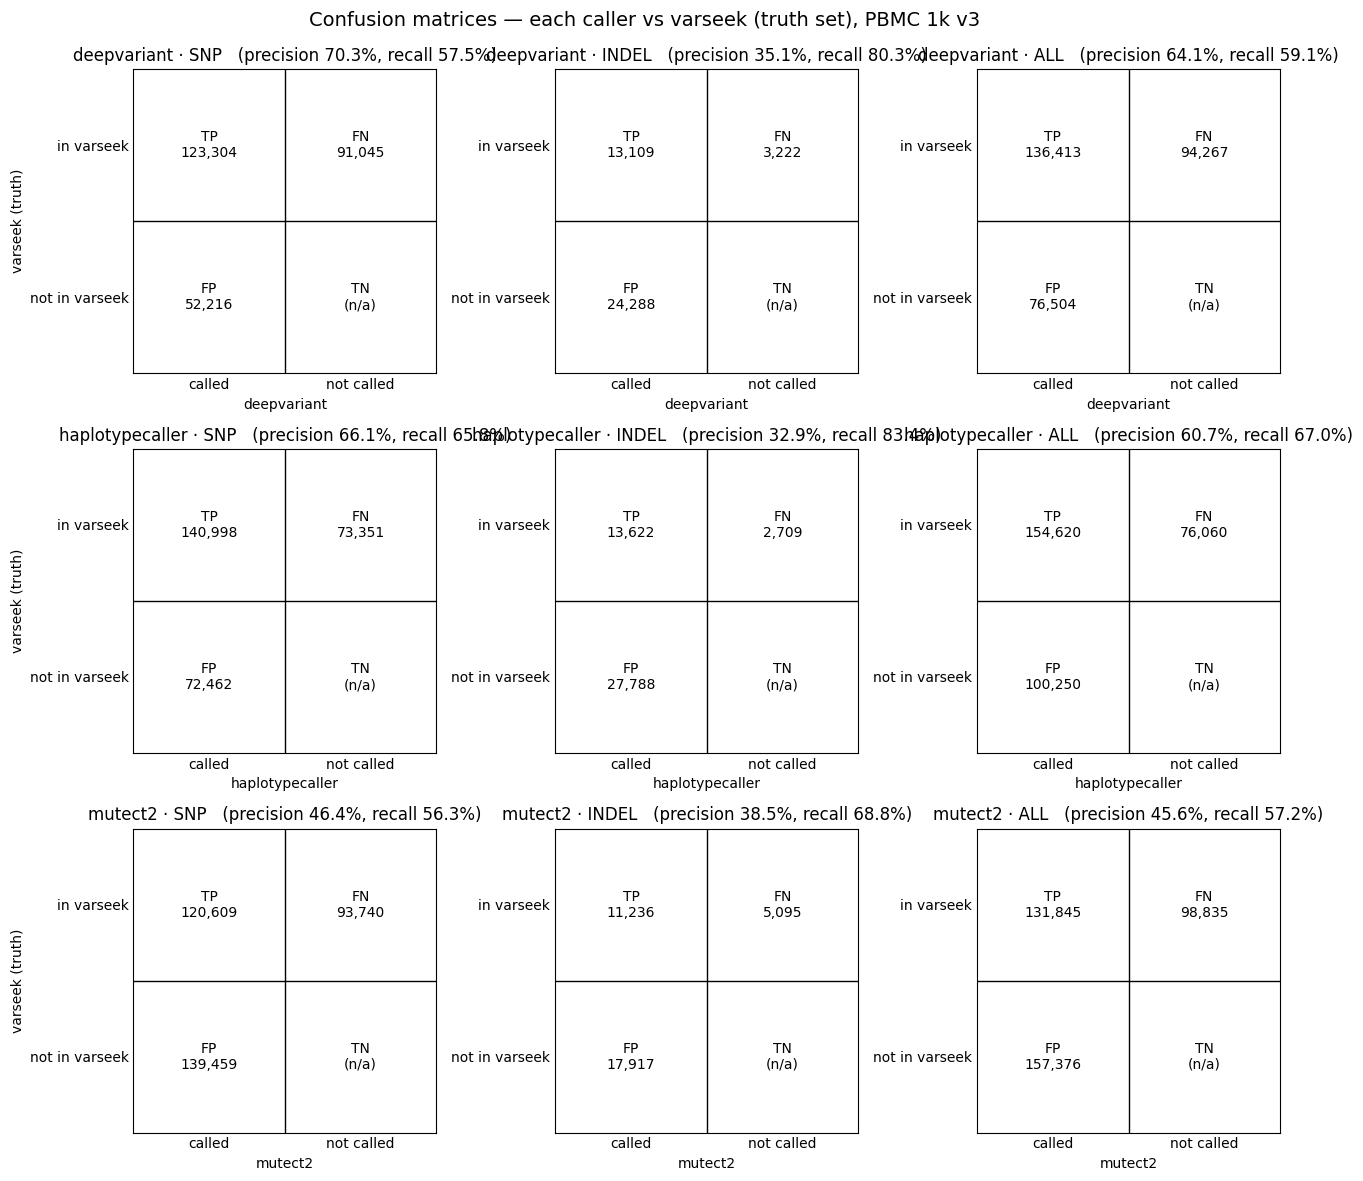

In [ ]:
# ---------------------------------------------------------------------------
# Confusion matrices per caller, with varseek as the truth set.
# Each caller was scored by hap.py against varseek (varseek = TRUTH, caller =
# QUERY), so the counts come straight from each summary:
#   TP = TRUTH.TP  (varseek call the caller also makes)
#   FP = QUERY.FP  (caller call absent from varseek)
#   FN = TRUTH.FN  (varseek call the caller misses)
# The TN cell (a variant neither tool calls) is undefined for an open-ended
# variant search, so it is left as n/a -- the same convention as the NA12878
# notebook's confusion matrices.
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt

CALLERS = ["deepvariant", "haplotypecaller", "mutect2"]

cms_by_tool = {}
for caller in CALLERS:
    summary_csv_path = os.path.join(happy_out, f"varseek_vs_{caller}.summary.csv")
    if not os.path.isfile(summary_csv_path):
        print(f"Summary for {caller} not found at {summary_csv_path}; skipping.")
        continue
    s = pd.read_csv(summary_csv_path)
    s = s[s["Filter"] == "PASS"].set_index("Type")
    cms = {t: (int(s.loc[t, "TRUTH.TP"]), int(s.loc[t, "QUERY.FP"]), int(s.loc[t, "TRUTH.FN"]))
           for t in ("SNP", "INDEL")}
    cms["ALL"] = tuple(sum(v) for v in zip(cms["SNP"], cms["INDEL"]))
    cms_by_tool[caller] = cms

print("Confusion counts vs varseek (truth); FN shown for reference, excluded from matrices:")
for caller, cms in cms_by_tool.items():
    for name, (tp, fp, fn) in cms.items():
        print(f"  {caller:16s} {name:5s}  TP={tp:>7,}  FP={fp:>7,}  FN={fn:>7,}  "
              f"precision={tp/(tp+fp):.1%}, recall={tp/(tp+fn):.1%}")

# One row of SNP / INDEL / ALL matrices per caller.
tools = list(cms_by_tool)
fig, axes = plt.subplots(len(tools), 3, figsize=(13, 4 * len(tools)), squeeze=False)
for r, caller in enumerate(tools):
    for ax, (name, (tp, fp, fn)) in zip(axes[r], cms_by_tool[caller].items()):
        # rows = varseek truth (in / not in), cols = caller call (called / not called);
        # the FN and TN cells are shown for reference but excluded from precision/recall shading.
        cells = [[f"TP\n{tp:,}", f"FN\n{fn:,}"],
                 [f"FP\n{fp:,}", "TN\n(n/a)"]]
        for i in range(2):
            for j in range(2):
                ax.text(j, i, cells[i][j], ha="center", va="center", fontsize=10, color="black")
        ax.set_xlim(-0.5, 1.5); ax.set_ylim(1.5, -0.5)   # row 0 at top
        ax.axhline(0.5, color="black", lw=1); ax.axvline(0.5, color="black", lw=1)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["called", "not called"])
        ax.set_yticks([0, 1]); ax.set_yticklabels(["in varseek", "not in varseek"])
        ax.tick_params(length=0)
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_color("black")
        ax.set_title(f"{caller} · {name}   (precision {tp/(tp+fp):.1%}, recall {tp/(tp+fn):.1%})")
        ax.set_xlabel(caller)
    axes[r][0].set_ylabel("varseek (truth)")
fig.suptitle("Confusion matrices — each caller vs varseek (truth set), PBMC 1k v3", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.99])
cm_png = os.path.join(happy_out, "confusion_matrices_by_tool.png")
fig.savefig(cm_png, dpi=150, bbox_inches="tight")
print(f"\nSaved confusion matrices to {cm_png}")
plt.show()

### Upset plot: variant call overlap across callers

Compare the variant call sets of varseek, DeepVariant, GATK HaplotypeCaller, and GATK Mutect2 as an upset plot, using the normalized VCFs so all callers share a common coordinate representation.

In [45]:
variants_vcf_filtered = filter_to_variant_calls(variants_vcf)
_ = make_normalized_vcf(variants_vcf_filtered, sequences)

Filtered file data/pbmc_1k_v3_variants/variants_nonref.vcf.gz already exists. Skipping filtering.
Normalized file data/pbmc_1k_v3_variants/variants_nonref_normalized.vcf.gz already exists. Skipping normalization.
time: 336 ms (started: 2026-06-11 16:43:23 -07:00)


varseek: 230,680 variants (data/varseek_count_out_pbmc_1k_v3/varseek_variants_normalized.vcf)
deepvariant: 212,980 variants (data/gatk_out/vcf_output/deepvariant_variants_nonref_normalized.vcf.gz)
haplotypecaller: 255,021 variants (data/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref_normalized.vcf.gz)
mutect2: 289,375 variants (data/gatk_out/vcfs/mutect2/mutect2_output_filtered_applied_nonref_normalized.vcf.gz)
bcftools: 325,583 variants (data/pbmc_1k_v3_variants/variants_nonref_normalized.vcf.gz)
Saved upset plot to data/happy_output/upset_callers.png


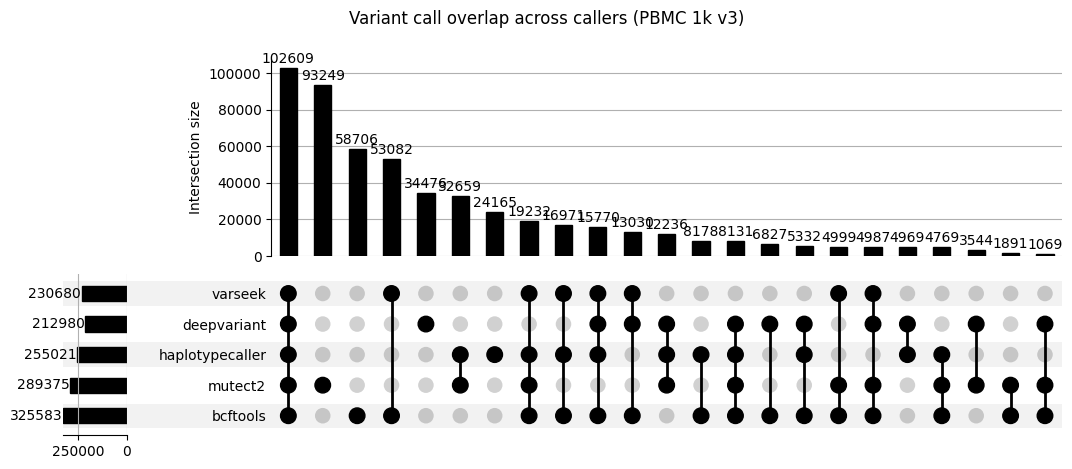

time: 8.11 s (started: 2026-06-11 16:43:23 -07:00)


In [46]:
try:
    import upsetplot
except ImportError:
    print("upsetplot not found, installing...")
    !pip install -U -q upsetplot
    import upsetplot

import gzip
import matplotlib.pyplot as plt
from upsetplot import from_contents, UpSet


def read_variant_set(vcf_path):
    """Read a (optionally gzipped) VCF into a set of (CHROM, POS, REF, ALT) keys.
    Multiallelic ALTs are split so each allele is counted separately."""
    if not vcf_path or not os.path.exists(vcf_path):
        return None
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    keys = set()
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            cols = line.rstrip("\n").split("\t")
            if len(cols) < 5:
                continue
            chrom, pos, _id, ref, alt = cols[:5]
            for a in alt.split(","):
                keys.add((chrom, pos, ref, a))
    return keys


# Use the normalized (left-aligned, multiallelic-split) VCFs so all four callers
# share a common coordinate representation. varseek is a variant-sites-only set;
# the GATK/DeepVariant callers are filtered to non-reference calls (_nonref) before
# normalization inside compare_with_happy().
caller_vcfs = {
    "varseek": add_normalized_before_first_dot(vk_count_variants_vcf),
    "deepvariant": add_normalized_before_first_dot(insert_suffix_before_first_dot(deepvariant_vcf, "_nonref")),
    "haplotypecaller": add_normalized_before_first_dot(insert_suffix_before_first_dot(haplotypecaller_vcf, "_nonref")),
    "mutect2": add_normalized_before_first_dot(insert_suffix_before_first_dot(mutect2_vcf, "_nonref")),
    "bcftools": add_normalized_before_first_dot(insert_suffix_before_first_dot(variants_vcf, "_nonref"))
}

caller_sets = {}
for name, path in caller_vcfs.items():
    s = read_variant_set(path)
    if s is None:
        print(f"WARNING: normalized VCF for {name} not found at {path}; excluding from upset plot.")
        continue
    caller_sets[name] = s
    print(f"{name}: {len(s):,} variants ({path})")

if len(caller_sets) >= 2:
    upset_data = from_contents(caller_sets)
    fig = plt.figure(figsize=(11, 6))
    UpSet(upset_data, subset_size="count", show_counts=True, sort_by="cardinality", sort_categories_by="-input").plot(fig=fig)
    fig.suptitle("Variant call overlap across callers (PBMC 1k v3)")

    upset_png = os.path.join(happy_out, "upset_callers.png")
    os.makedirs(happy_out, exist_ok=True)
    fig.savefig(upset_png, dpi=150, bbox_inches="tight")
    print(f"Saved upset plot to {upset_png}")
    plt.show()
else:
    print("Need at least two caller sets to build an upset plot.")

### Benchmark against VarTrix

[VarTrix](https://github.com/10XGenomics/vartrix) genotypes a set of pre-called variants against a single-cell BAM, producing a cell × variant matrix of ref/alt read support — the single-cell analog of `vk count`. Here we feed it the de novo variants called above (`variants.vcf.gz`, the VCF form of `variants.tsv`).

VarTrix requires a Cell Ranger-style BAM carrying `CB` (cell barcode) and `UB` (UMI) tags plus the called-cell barcode whitelist. The STAR alignment used for de novo calling is a bulk alignment of the combined R2 reads and has neither, so we first run `cellranger count --create-bam=true` on the raw 10x FASTQs to generate both. Because the Cell Ranger 2024-A reference uses `chr`-prefixed contig names (`chr1`, `chrM`, …), the variant VCF is renamed from Ensembl naming (`1`, `MT`, …) to match before genotyping. VarTrix then runs against Cell Ranger's own reference FASTA (`genome.fa`), which the BAM was aligned to.

In [47]:
# --- VarTrix benchmark paths ---
cellranger_binary = "/home/jrich/opt/cellranger-9.0.1/cellranger"
cellranger_transcriptome = "/home/jrich/opt/refdata-gex-GRCh38-2024-A"
cellranger_ref_fasta = os.path.join(cellranger_transcriptome, "fasta", "genome.fa")

cellranger_id = "pbmc_1k_v3_cellranger"
cellranger_sample = "pbmc_1k_v3"
cellranger_out_dir = os.path.join("data", cellranger_id)
cellranger_bam = os.path.join(cellranger_out_dir, "outs", "possorted_genome_bam.bam")
cellranger_barcodes_gz = os.path.join(cellranger_out_dir, "outs", "filtered_feature_bc_matrix", "barcodes.tsv.gz")

vartrix_out_dir = os.path.join("data", "vartrix_out_pbmc_1k_v3")
os.makedirs(vartrix_out_dir, exist_ok=True)
vartrix_vcf = os.path.join(vartrix_out_dir, "variants_vartrix.vcf")
vartrix_barcodes = os.path.join(vartrix_out_dir, "barcodes.tsv")
vartrix_alt_matrix = os.path.join(vartrix_out_dir, "alt_matrix.mtx")
vartrix_ref_matrix = os.path.join(vartrix_out_dir, "ref_matrix.mtx")
vartrix_variants_txt = os.path.join(vartrix_out_dir, "variant_loci.txt")

# Locate the VarTrix binary. /home/jrich/opt/vartrix-1.1.22 holds only source
# (and there is no cargo toolchain), so fall back to the prebuilt linux release.
vartrix_binary = "/home/jrich/opt/vartrix_linux"
if not (os.path.isfile(vartrix_binary) and os.access(vartrix_binary, os.X_OK)):
    print("VarTrix binary not found; downloading prebuilt v1.1.22 linux release...")
    !wget -q -O {vartrix_binary} https://github.com/10XGenomics/vartrix/releases/download/v1.1.22/vartrix_linux
    !chmod +x {vartrix_binary}
!{vartrix_binary} --version

vartrix 1.1.22
time: 445 ms (started: 2026-06-11 16:43:31 -07:00)


In [48]:
# Run Cell Ranger count to produce a single-cell BAM carrying CB (cell barcode)
# and UB (UMI) tags plus the called-cell barcode whitelist -- both required by
# VarTrix. The STAR alignment used for de novo calling is a bulk alignment of the
# combined R2 reads and has neither. Cell Ranger 9 disables BAM output by default,
# so --create-bam=true is required. The --sample filter restricts input to the
# pbmc_1k_v3_S1_L00*_R*_001.fastq.gz files, ignoring combined_R2.fastq.gz.
if not os.path.exists(cellranger_bam):
    !cd data && {cellranger_binary} count \
        --id={cellranger_id} \
        --transcriptome={cellranger_transcriptome} \
        --fastqs=pbmc_1k_v3_fastqs \
        --sample={cellranger_sample} \
        --create-bam=true \
        --localcores={threads} \
        --localmem=64

time: 627 μs (started: 2026-06-11 16:43:32 -07:00)


In [49]:
import gzip

# Map Ensembl primary-assembly chromosome names to the Cell Ranger 2024-A
# reference convention (chr-prefixed; MT -> chrM). Unplaced scaffolds (KI.../GL...)
# share the same accession in both references, so they pass through unchanged.
chrom_rename = {str(i): f"chr{i}" for i in range(1, 23)}
chrom_rename.update({"X": "chrX", "Y": "chrY", "MT": "chrM"})

# Valid contigs = those in the Cell Ranger reference FASTA index. A variant on a
# contig absent from the BAM would make VarTrix abort, so drop those records.
valid_contigs = set()
with open(f"{cellranger_ref_fasta}.fai") as f:
    for line in f:
        valid_contigs.add(line.split("\t")[0])

# Build the VarTrix input VCF from the de novo calls (variants.vcf.gz is the VCF
# form of variants.tsv), renaming contigs to match the Cell Ranger BAM/FASTA.
if not os.path.exists(vartrix_vcf):
    n_written = n_skipped = 0
    with gzip.open(variants_vcf, "rt") as fin, open(vartrix_vcf, "w") as fout:
        for line in fin:
            if line.startswith("##contig=<ID="):
                m = re.match(r"##contig=<ID=([^,>]+)(.*)>", line.rstrip("\n"))
                cid = chrom_rename.get(m.group(1), m.group(1))
                if cid in valid_contigs:
                    fout.write(f"##contig=<ID={cid}{m.group(2)}>\n")
                continue
            if line.startswith("#"):
                fout.write(line)
                continue
            cols = line.rstrip("\n").split("\t")
            cols[0] = chrom_rename.get(cols[0], cols[0])
            if cols[0] not in valid_contigs:
                n_skipped += 1
                continue
            fout.write("\t".join(cols) + "\n")
            n_written += 1
    print(f"Wrote {n_written:,} variants to {vartrix_vcf} ({n_skipped:,} on absent contigs skipped)")

# VarTrix wants an uncompressed, one-barcode-per-line cell barcode file.
if not os.path.exists(vartrix_barcodes):
    with gzip.open(cellranger_barcodes_gz, "rt") as fin, open(vartrix_barcodes, "w") as fout:
        fout.write(fin.read())
print(f"{sum(1 for _ in open(vartrix_barcodes)):,} cell barcodes")

1,221 cell barcodes
time: 13.6 ms (started: 2026-06-11 16:43:32 -07:00)


In [50]:
# Genotype the de novo-called variants against the single-cell BAM. coverage mode
# emits two cell x variant count matrices: the alt-read matrix to --out-matrix and
# the ref-read matrix to --ref-matrix. --umi collapses reads to a per-UMI consensus
# so the counts are UMI-level, matching how vk count tallies evidence.
if not os.path.exists(vartrix_alt_matrix):
    !{vartrix_binary} \
        --vcf {vartrix_vcf} \
        --bam {cellranger_bam} \
        --fasta {cellranger_ref_fasta} \
        --cell-barcodes {vartrix_barcodes} \
        --out-matrix {vartrix_alt_matrix} \
        --ref-matrix {vartrix_ref_matrix} \
        --out-variants {vartrix_variants_txt} \
        --scoring-method coverage \
        --umi \
        --threads {threads} \
        --log-level info

time: 24.1 ms (started: 2026-06-11 16:43:32 -07:00)


In [51]:
import scipy.io

# VarTrix matrices are variants (rows) x barcodes (cols); transpose to the
# cells x variants layout used by the varseek AnnData objects.
vartrix_alt = scipy.io.mmread(vartrix_alt_matrix).tocsr().T.tocsr()
vartrix_ref = scipy.io.mmread(vartrix_ref_matrix).tocsr().T.tocsr()

vartrix_barcode_list = [line.strip() for line in open(vartrix_barcodes)]

# Matrix rows follow the input VCF record order, so read REF/ALT straight from
# the renamed VCF to build fully-qualified variant ids.
vartrix_vcf_records = [
    line.rstrip("\n").split("\t")
    for line in open(vartrix_vcf)
    if not line.startswith("#")
]
vartrix_variant_ids = [f"{c[0]}_{c[1]}_{c[3]}_{c[4]}" for c in vartrix_vcf_records]

vartrix_adata = ad.AnnData(
    X=vartrix_alt,
    obs=pd.DataFrame(index=vartrix_barcode_list),
    var=pd.DataFrame(index=vartrix_variant_ids),
)
vartrix_adata.layers["ref"] = vartrix_ref

# Cells with >=1 alt-supporting UMI per variant.
alt_cells_per_variant = (vartrix_alt > 0).sum(axis=0).A1
n_detected = int((alt_cells_per_variant > 0).sum())
print(f"VarTrix genotyped {vartrix_adata.n_obs:,} cells x {vartrix_adata.n_vars:,} variants")
print(f"Variants with >=1 alt-supporting cell: {n_detected:,} "
      f"({100 * n_detected / vartrix_adata.n_vars:.1f}%)")

vartrix_adata_path = os.path.join(vartrix_out_dir, "vartrix_adata.h5ad")
vartrix_adata.write_h5ad(vartrix_adata_path)
print(f"Saved VarTrix genotype matrix to {vartrix_adata_path}")

# Write the variants VarTrix confirms (>=1 alt-supporting cell) as a sites-only
# VCF in Ensembl coordinates, so it is drop-in compatible with the upset/hap.py
# comparison cells above alongside the other callers.
inv_chrom_rename = {v: k for k, v in chrom_rename.items()}
vartrix_confirmed_vcf = os.path.join(vartrix_out_dir, "vartrix_variants.vcf")
detected_mask = alt_cells_per_variant > 0
with open(vartrix_confirmed_vcf, "w") as f:
    f.write("##fileformat=VCFv4.2\n")
    f.write("#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n")
    for rec, keep in zip(vartrix_vcf_records, detected_mask):
        if not keep:
            continue
        chrom = inv_chrom_rename.get(rec[0], rec[0])
        f.write(f"{chrom}\t{rec[1]}\t.\t{rec[3]}\t{rec[4]}\t.\t.\t.\n")
print(f"Wrote {int(detected_mask.sum()):,} VarTrix-confirmed variants to {vartrix_confirmed_vcf}")

VarTrix genotyped 1,221 cells x 325,583 variants
Variants with >=1 alt-supporting cell: 275,090 (84.5%)
Saved VarTrix genotype matrix to data/vartrix_out_pbmc_1k_v3/vartrix_adata.h5ad
Wrote 275,090 VarTrix-confirmed variants to data/vartrix_out_pbmc_1k_v3/vartrix_variants.vcf
time: 2.77 s (started: 2026-06-11 16:43:32 -07:00)


In [52]:
happy_out = os.path.join("data", "happy_output")
# if not use_unfiltered_varseek:
#     happy_out += "_filtered"

for label, alternate_vcf in [("vatrix", vartrix_confirmed_vcf)]:
    if not os.path.exists(alternate_vcf):
        print(f"Alternate VCF {alternate_vcf} does not exist. Skipping comparison for {label}.")
        continue
    compare_with_happy(
        varseek_vcf=vk_count_variants_vcf,
        alternate_vcf=alternate_vcf,
        reference_fasta=sequences,
        output_dir=happy_out,
        output_prefix=f"varseek_vs_{label}"
    )

Normalized file /home/jrich/Desktop/varseek-examples/data/vartrix_out_pbmc_1k_v3/vartrix_variants_normalized.vcf already exists. Skipping normalization.


Normalized file /home/jrich/Desktop/varseek-examples/data/varseek_count_out_pbmc_1k_v3/varseek_variants_normalized.vcf already exists. Skipping normalization.
Summary file /home/jrich/Desktop/varseek-examples/data/happy_output/varseek_vs_vatrix.summary.csv already exists. Skipping hap.py run.
time: 148 ms (started: 2026-06-11 16:43:35 -07:00)


varseek: 230,680 variants (data/varseek_count_out_pbmc_1k_v3/varseek_variants_normalized.vcf)
deepvariant: 212,980 variants (data/gatk_out/vcf_output/deepvariant_variants_nonref_normalized.vcf.gz)
haplotypecaller: 255,021 variants (data/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref_normalized.vcf.gz)
mutect2: 289,375 variants (data/gatk_out/vcfs/mutect2/mutect2_output_filtered_applied_nonref_normalized.vcf.gz)
vatrix: 275,090 variants (data/vartrix_out_pbmc_1k_v3/vartrix_variants_normalized.vcf)
Saved upset plot to data/happy_output/upset_callers.png


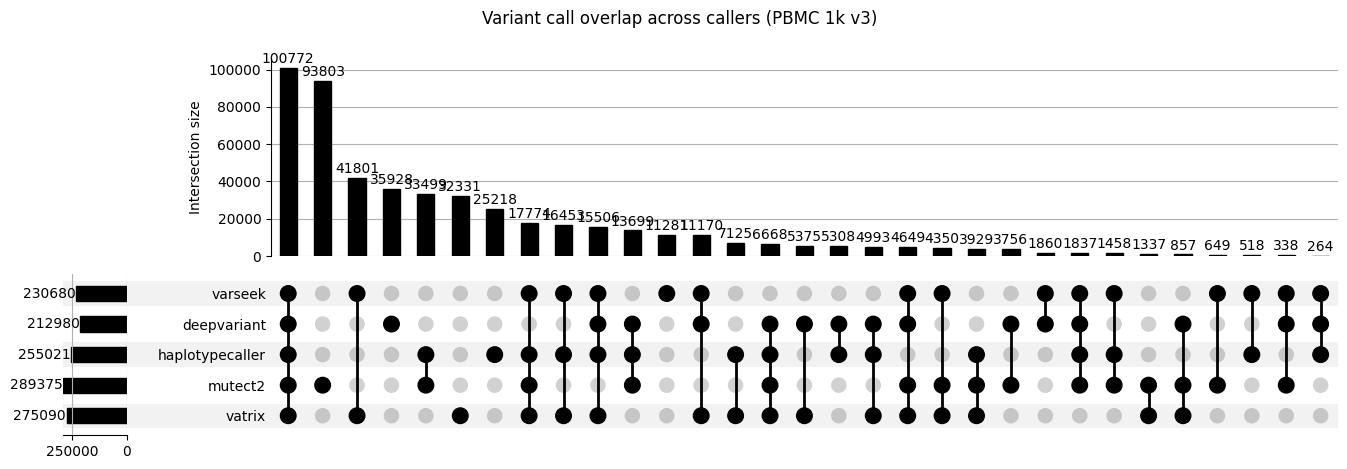

time: 8.29 s (started: 2026-06-11 16:43:35 -07:00)


In [53]:
try:
    import upsetplot
except ImportError:
    print("upsetplot not found, installing...")
    !pip install -U -q upsetplot
    import upsetplot

import gzip
import matplotlib.pyplot as plt
from upsetplot import from_contents, UpSet


def read_variant_set(vcf_path):
    """Read a (optionally gzipped) VCF into a set of (CHROM, POS, REF, ALT) keys.
    Multiallelic ALTs are split so each allele is counted separately."""
    if not vcf_path or not os.path.exists(vcf_path):
        return None
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    keys = set()
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            cols = line.rstrip("\n").split("\t")
            if len(cols) < 5:
                continue
            chrom, pos, _id, ref, alt = cols[:5]
            for a in alt.split(","):
                keys.add((chrom, pos, ref, a))
    return keys


# Use the normalized (left-aligned, multiallelic-split) VCFs so all four callers
# share a common coordinate representation. varseek is a variant-sites-only set;
# the GATK/DeepVariant callers are filtered to non-reference calls (_nonref) before
# normalization inside compare_with_happy().
caller_vcfs = {
    "varseek": add_normalized_before_first_dot(vk_count_variants_vcf),
    "deepvariant": add_normalized_before_first_dot(insert_suffix_before_first_dot(deepvariant_vcf, "_nonref")),
    "haplotypecaller": add_normalized_before_first_dot(insert_suffix_before_first_dot(haplotypecaller_vcf, "_nonref")),
    "mutect2": add_normalized_before_first_dot(insert_suffix_before_first_dot(mutect2_vcf, "_nonref")),
    "vatrix": add_normalized_before_first_dot(vartrix_confirmed_vcf),
    # "bcftools": add_normalized_before_first_dot(insert_suffix_before_first_dot(variants_vcf, "_nonref"))
}

caller_sets = {}
for name, path in caller_vcfs.items():
    s = read_variant_set(path)
    if s is None:
        print(f"WARNING: normalized VCF for {name} not found at {path}; excluding from upset plot.")
        continue
    caller_sets[name] = s
    print(f"{name}: {len(s):,} variants ({path})")

if len(caller_sets) >= 2:
    upset_data = from_contents(caller_sets)
    fig = plt.figure(figsize=(11, 6))
    UpSet(upset_data, subset_size="count", show_counts=True, sort_by="cardinality", sort_categories_by="-input").plot(fig=fig)
    fig.suptitle("Variant call overlap across callers (PBMC 1k v3)")

    upset_png = os.path.join(happy_out, "upset_callers.png")
    os.makedirs(happy_out, exist_ok=True)
    fig.savefig(upset_png, dpi=150, bbox_inches="tight")
    print(f"Saved upset plot to {upset_png}")
    plt.show()
else:
    print("Need at least two caller sets to build an upset plot.")

### Are the variants only Mutect2 detects likely real?

The upset plot above shows that Mutect2 reports a large block of variants that **no other caller** (varseek, DeepVariant, GATK HaplotypeCaller, VarTrix) recovers. Are these genuine variants the other tools miss, or are they mostly Mutect2-specific false positives?

We can't observe ground truth here, but we have three orthogonal lines of evidence:

1. **Corroboration as a proxy for truth.** Split Mutect2's PASS calls into *Mutect2-only* (in Mutect2 and **none** of the other callers) vs. *corroborated* (in Mutect2 **and** ≥1 other caller). Independent methods agreeing makes the corroborated set a reasonable "likely-real" reference, so we ask how the Mutect2-only set differs from it.

2. **Mutect2's own per-call evidence.** Read depth (`DP`), alt-allele read count (`AD`), allele fraction (`AF`), and model confidence (`TLOD`) say how much support each call has. A call resting on a single read is the classic signature of an RNA-seq / sequencing artifact.

3. **Population-genetics signals.** The transition/transversion (Ti/Tv) ratio of true human SNVs is ~2–3, whereas random sequencing errors trend toward ~0.5; and genuine variants in a healthy donor are overwhelmingly germline, so they should appear in the 1000 Genomes catalogue (final cell).

All comparisons use the normalized (`_nonref_normalized`) VCFs, so variant keys line up with the upset plot above.

Union of orthogonal callers: 410,703 variant alleles

Mutect2 PASS alleles: 289,375
  corroborated (>=1 other caller): 195,572 (67.6%)
  mutect2-only (no other caller):  93,803 (32.4%)

Per-call evidence by group:


,mutect2-only,corroborated
n,93803.000,195572.000
% single alt read,68.366,1.526
% indel,5.751,12.168
Ti/Tv (SNVs),2.433,2.868
median DP,1.000,5.000
median alt_AD,1.000,3.000
median AF,0.667,0.750
median TLOD,4.200,8.530
median GERMQ,43.000,45.000
median MPOS,26.000,25.000



Saved figure to data/happy_output/mutect2_only_evidence.png


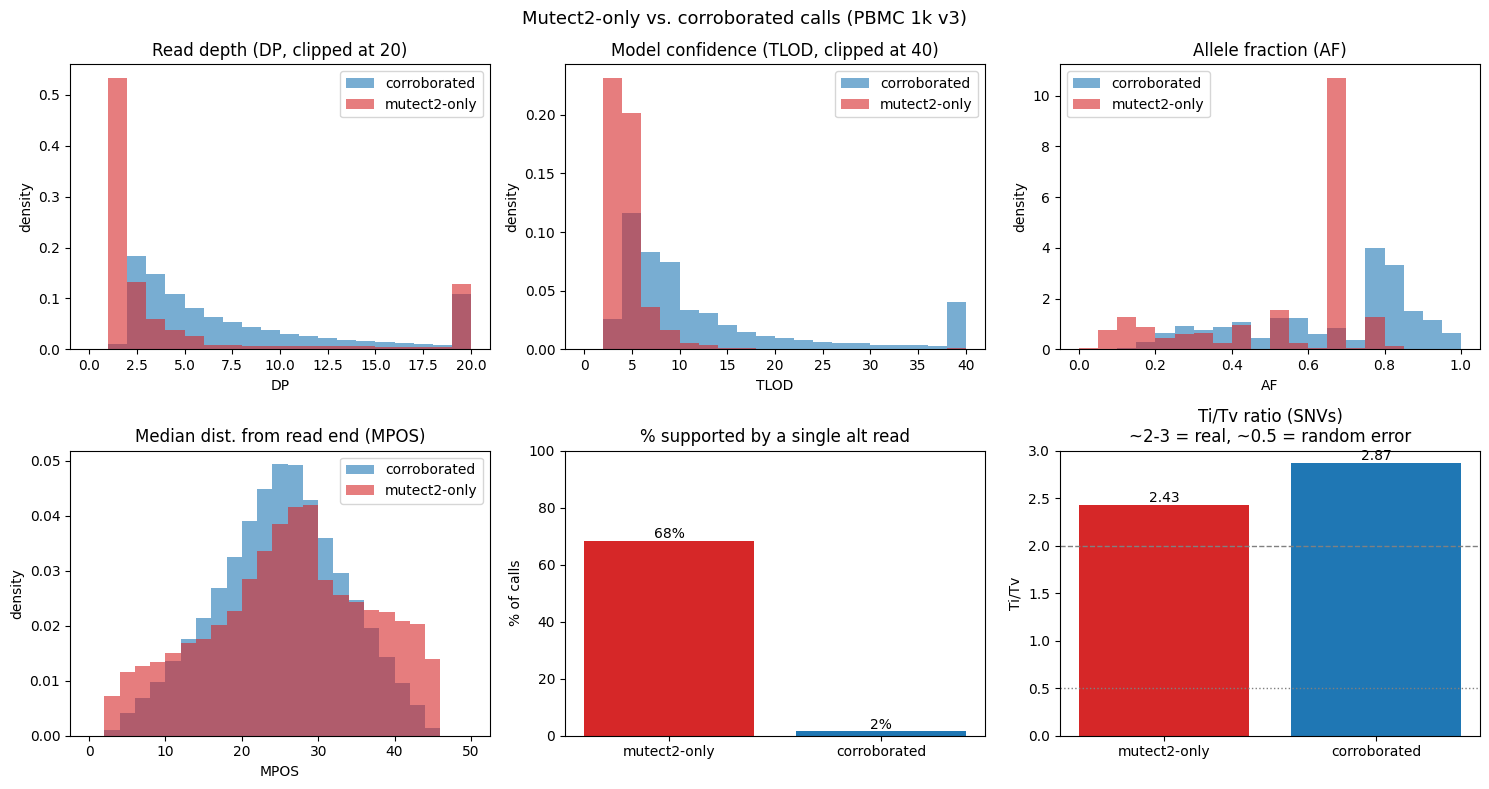

time: 7.82 s (started: 2026-06-11 16:43:43 -07:00)


In [54]:
import os
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Partition Mutect2's PASS calls into "mutect2-only" vs "corroborated", using
# the same normalized VCFs the upset plot used so keys line up exactly.
# ---------------------------------------------------------------------------
mutect2_norm = add_normalized_before_first_dot(insert_suffix_before_first_dot(mutect2_vcf, "_nonref"))

orthogonal_vcfs = {
    "varseek":         add_normalized_before_first_dot(vk_count_variants_vcf),
    "deepvariant":     add_normalized_before_first_dot(insert_suffix_before_first_dot(deepvariant_vcf, "_nonref")),
    "haplotypecaller": add_normalized_before_first_dot(insert_suffix_before_first_dot(haplotypecaller_vcf, "_nonref")),
    "vartrix":         add_normalized_before_first_dot(vartrix_confirmed_vcf),
}

other_calls = set()
for name, path in orthogonal_vcfs.items():
    s = read_variant_set(path)
    if s is None:
        print(f"WARNING: normalized VCF for {name} not found at {path}; excluding from corroboration set.")
        continue
    other_calls |= s
print(f"Union of orthogonal callers: {len(other_calls):,} variant alleles\n")

# ---------------------------------------------------------------------------
# Parse every Mutect2 record, pulling its per-call evidence, and tag the group.
# Fields: DP/AD/AF (FORMAT, per-sample), TLOD/GERMQ/MPOS/MBQ/MMQ/POPAF (INFO).
# ---------------------------------------------------------------------------
TRANSITIONS = {("A", "G"), ("G", "A"), ("C", "T"), ("T", "C")}

def _info_dict(info):
    return dict(f.split("=", 1) for f in info.split(";") if "=" in f)

def _first(x):
    """First (alt) value of a possibly comma-separated field, as float."""
    try:
        return float(str(x).split(",")[0])
    except (ValueError, AttributeError):
        return np.nan

def _alt(x):
    """Second (alt) value of a ref,alt field (e.g. AD, MBQ, MMQ), as float."""
    try:
        return float(str(x).split(",")[1])
    except (ValueError, IndexError, AttributeError):
        return np.nan

rows = []
with gzip.open(mutect2_norm, "rt") as f:
    for line in f:
        if line.startswith("#"):
            continue
        cols = line.rstrip("\n").split("\t")
        chrom, pos, _id, ref, alt, _qual, _filt, info, fmt, sample = cols[:10]
        key = (chrom, pos, ref, alt)
        sd = dict(zip(fmt.split(":"), sample.split(":")))
        idict = _info_dict(info)
        is_snv = len(ref) == 1 and len(alt) == 1 and ref in "ACGT" and alt in "ACGT"
        rows.append({
            "key": key,
            "group": "corroborated" if key in other_calls else "mutect2-only",
            "is_snv": is_snv,
            "is_indel": len(ref) != len(alt),
            "ti": is_snv and (ref, alt) in TRANSITIONS,
            "tv": is_snv and (ref, alt) not in TRANSITIONS,
            "DP": _first(sd.get("DP")),
            "alt_AD": _alt(sd.get("AD")),
            "AF": _first(sd.get("AF")),
            "TLOD": _first(idict.get("TLOD")),
            "GERMQ": _first(idict.get("GERMQ")),
            "MPOS": _first(idict.get("MPOS")),
            "MBQ_alt": _alt(idict.get("MBQ")),
            "MMQ_alt": _alt(idict.get("MMQ")),
            "POPAF": _first(idict.get("POPAF")),
        })

m2 = pd.DataFrame(rows)
m2["single_read"] = m2["alt_AD"] <= 1   # call rests on a single alt-supporting read

n_only = int((m2["group"] == "mutect2-only").sum())
print(f"Mutect2 PASS alleles: {len(m2):,}")
print(f"  corroborated (>=1 other caller): {len(m2) - n_only:,} ({100*(len(m2)-n_only)/len(m2):.1f}%)")
print(f"  mutect2-only (no other caller):  {n_only:,} ({100*n_only/len(m2):.1f}%)")

# ---------------------------------------------------------------------------
# Per-group summary table.
# ---------------------------------------------------------------------------
def group_summary(df):
    ti, tv = int(df["ti"].sum()), int(df["tv"].sum())
    out = {
        "n": len(df),
        "% single alt read": 100 * df["single_read"].mean(),
        "% indel": 100 * df["is_indel"].mean(),
        "Ti/Tv (SNVs)": (ti / tv) if tv else np.nan,
    }
    for c in ["DP", "alt_AD", "AF", "TLOD", "GERMQ", "MPOS", "MBQ_alt", "MMQ_alt", "POPAF"]:
        out[f"median {c}"] = df[c].median()
    return out

summary = pd.DataFrame(
    {g: group_summary(d) for g, d in m2.groupby("group")}
)[["mutect2-only", "corroborated"]]
print("\nPer-call evidence by group:")
display(summary.round(3))

# ---------------------------------------------------------------------------
# Visual comparison.
# ---------------------------------------------------------------------------
only = m2[m2["group"] == "mutect2-only"]
corr = m2[m2["group"] == "corroborated"]
COL = {"mutect2-only": "#d62728", "corroborated": "#1f77b4"}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

def hist_pair(ax, col, bins, title, xlabel, clip=None):
    o = only[col].clip(upper=clip) if clip else only[col]
    c = corr[col].clip(upper=clip) if clip else corr[col]
    ax.hist(c.dropna(), bins=bins, density=True, alpha=0.6, label="corroborated", color=COL["corroborated"])
    ax.hist(o.dropna(), bins=bins, density=True, alpha=0.6, label="mutect2-only", color=COL["mutect2-only"])
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel("density"); ax.legend()

hist_pair(axes[0, 0], "DP",   np.arange(0, 21, 1),    "Read depth (DP, clipped at 20)", "DP", clip=20)
hist_pair(axes[0, 1], "TLOD", np.arange(0, 41, 2),    "Model confidence (TLOD, clipped at 40)", "TLOD", clip=40)
hist_pair(axes[0, 2], "AF",   np.linspace(0, 1, 21),  "Allele fraction (AF)", "AF")
hist_pair(axes[1, 0], "MPOS", np.arange(0, 51, 2),    "Median dist. from read end (MPOS)", "MPOS", clip=50)

# % single-read bar
ax = axes[1, 1]
vals = [100 * only["single_read"].mean(), 100 * corr["single_read"].mean()]
ax.bar(["mutect2-only", "corroborated"], vals, color=[COL["mutect2-only"], COL["corroborated"]])
for i, v in enumerate(vals):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center")
ax.set_title("% supported by a single alt read"); ax.set_ylabel("% of calls"); ax.set_ylim(0, 100)

# Ti/Tv bar
ax = axes[1, 2]
def titv(df):
    ti, tv = int(df["ti"].sum()), int(df["tv"].sum())
    return (ti / tv) if tv else np.nan
vals = [titv(only), titv(corr)]
ax.bar(["mutect2-only", "corroborated"], vals, color=[COL["mutect2-only"], COL["corroborated"]])
for i, v in enumerate(vals):
    ax.text(i, v + 0.03, f"{v:.2f}", ha="center")
ax.axhline(2.0, ls="--", c="gray", lw=1)
ax.axhline(0.5, ls=":", c="gray", lw=1)
ax.set_title("Ti/Tv ratio (SNVs)\n~2-3 = real, ~0.5 = random error")
ax.set_ylabel("Ti/Tv"); ax.set_ylim(0, 3)

fig.suptitle("Mutect2-only vs. corroborated calls (PBMC 1k v3)", fontsize=13)
fig.tight_layout()
titv_fig_path = os.path.join(happy_out, "mutect2_only_evidence.png")
fig.savefig(titv_fig_path, dpi=150, bbox_inches="tight")
print(f"\nSaved figure to {titv_fig_path}")
plt.show()

Using cached 1000 Genomes hits: data/happy_output/mutect2_sites_in_1000G.tsv

1000 Genomes phase-3 records matched: 139,365 sites



,n,% on known 1000G site,% exact allele in 1000G
group,,,
mutect2-only,93803,23.39,20.99
corroborated,195572,60.04,59.36



Mutect2-only, stratified by read support:


,n,% on known 1000G site,Ti/Tv (SNVs)
multi-read,29674,14.98,3.78
single-read,64129,27.29,2.12



Saved figure to data/happy_output/mutect2_only_1000G_overlap.png


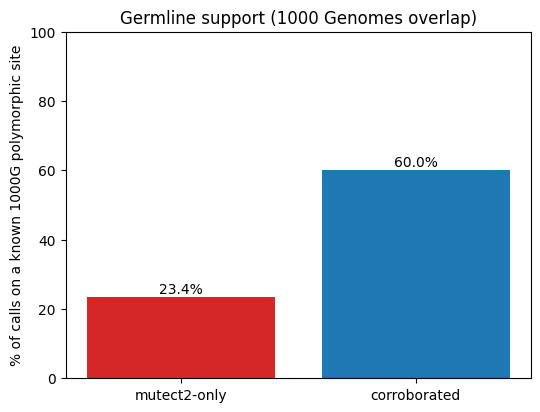

time: 727 ms (started: 2026-06-11 16:43:51 -07:00)


In [55]:
# ---------------------------------------------------------------------------
# Orthogonal germline check: how many Mutect2 calls sit on a known 1000 Genomes
# site? A healthy donor's real variants are overwhelmingly germline, so genuine
# calls should be enriched for known polymorphic sites; artifacts should not.
#
# This streams the (~12 GB) 1000 Genomes VCF once with `bcftools view -T`, which
# does NOT require an index, and caches the matching records. Set to False to skip.
# ---------------------------------------------------------------------------
RUN_GERMLINE_OVERLAP = True

germline_hits_tsv = os.path.join(happy_out, "mutect2_sites_in_1000G.tsv")

if RUN_GERMLINE_OVERLAP and os.path.exists(genomes1000_vcf):
    if not (os.path.isfile(germline_hits_tsv) and os.path.getsize(germline_hits_tsv) > 0):
        # Targets = every unique (CHROM, POS) Mutect2 calls. bcftools -T loads these
        # into an in-memory index, so file order does not matter.
        targets_tsv = os.path.join(happy_out, "mutect2_query_sites.tsv")
        sites = sorted({(k[0], int(k[1])) for k in m2["key"]})
        with open(targets_tsv, "w") as fh:
            fh.writelines(f"{c}\t{p}\n" for c, p in sites)
        print(f"Streaming 1000 Genomes for {len(sites):,} Mutect2 sites "
              f"(one pass over {genomes1000_vcf}, this can take a few minutes)...")
        with open(germline_hits_tsv, "w") as out:
            subprocess.run(["bcftools", "view", "-H", "-T", targets_tsv, genomes1000_vcf],
                           stdout=out, check=True)
    else:
        print(f"Using cached 1000 Genomes hits: {germline_hits_tsv}")

    # Build lookups: known polymorphic SITE (chrom,pos) and exact ALLELE match.
    pos_hits, allele_hits = set(), set()
    with open(germline_hits_tsv) as fh:
        for line in fh:
            cols = line.rstrip("\n").split("\t")
            if len(cols) < 5:
                continue
            chrom, pos, _id, ref, alt = cols[:5]
            pos_hits.add((chrom, pos))
            for a in alt.split(","):
                allele_hits.add((chrom, pos, ref, a))

    m2["in_1000G_site"] = m2["key"].map(lambda k: (k[0], k[1]) in pos_hits)
    m2["in_1000G_allele"] = m2["key"].map(lambda k: k in allele_hits)

    print(f"\n1000 Genomes phase-3 records matched: {len(pos_hits):,} sites\n")
    g = m2.groupby("group")
    germ = pd.DataFrame({
        "n": g.size(),
        "% on known 1000G site": 100 * g["in_1000G_site"].mean(),
        "% exact allele in 1000G": 100 * g["in_1000G_allele"].mean(),
    }).loc[["mutect2-only", "corroborated"]]
    display(germ.round(2))

    # Within mutect2-only, does the multi-read minority look more germline than
    # the single-read bulk? (i.e. is the "real" signal concentrated where there
    # is more than one supporting read?)
    only = m2[m2["group"] == "mutect2-only"]
    strat = only.groupby(np.where(only["single_read"], "single-read", "multi-read"))
    strat_tbl = pd.DataFrame({
        "n": strat.size(),
        "% on known 1000G site": 100 * strat["in_1000G_site"].mean(),
        "Ti/Tv (SNVs)": strat.apply(
            lambda d: (d["ti"].sum() / d["tv"].sum()) if d["tv"].sum() else np.nan
        ),
    })
    print("\nMutect2-only, stratified by read support:")
    display(strat_tbl.round(2))

    # Plot germline enrichment.
    fig, ax = plt.subplots(figsize=(6, 4.5))
    labels = ["mutect2-only", "corroborated"]
    vals = [germ.loc[l, "% on known 1000G site"] for l in labels]
    bars = ax.bar(labels, vals, color=["#d62728", "#1f77b4"])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.1f}%", ha="center")
    ax.set_ylabel("% of calls on a known 1000G polymorphic site")
    ax.set_title("Germline support (1000 Genomes overlap)")
    ax.set_ylim(0, 100)
    germ_fig_path = os.path.join(happy_out, "mutect2_only_1000G_overlap.png")
    fig.savefig(germ_fig_path, dpi=150, bbox_inches="tight")
    print(f"\nSaved figure to {germ_fig_path}")
    plt.show()
elif not os.path.exists(genomes1000_vcf):
    print(f"1000 Genomes VCF not found at {genomes1000_vcf}; skipping germline overlap.")
else:
    print("RUN_GERMLINE_OVERLAP is False; skipping the 1000 Genomes streaming step.")

#### Takeaway

The three lines of evidence agree on the headline and add a twist.

**Headline — most Mutect2-only calls have little independent support.** About 32% of Mutect2's PASS calls are Mutect2-only, and they look very different from the corroborated set:

- **Read support collapses.** ~68% rest on a *single* alt read (median `DP` = 1, median `TLOD` ≈ 4) versus ~1.5% of corroborated calls (median `DP` = 5). At depth 1, a single sequencing / reverse-transcription error is indistinguishable from a real variant — exactly the calls the other tools' depth/consensus thresholds (and varseek's `min_counts`) reject, which is why they end up Mutect2-private.
- **Germline overlap roughly halves.** Only ~23% of Mutect2-only calls sit on a known 1000 Genomes site, versus ~60% of corroborated calls.
- **Ti/Tv (≈2.4) sits between** the corroborated set (≈2.9) and the random-error floor (~0.5) — a *blend* of real variants and artifacts, not pure noise.

**The twist — the Mutect2-only set is two different non-real populations.** Stratifying by read support shows they are not one thing:

- *Single-read bulk* (~68% of Mutect2-only): lower Ti/Tv (~2.1) but the **higher** 1000G overlap (~27%). These include genuine low-coverage germline SNVs that happen to land on known sites but were dropped by the other callers purely for lack of depth — mixed in with single-read sequencing errors.
- *Multi-read minority* (~32% of Mutect2-only): very high Ti/Tv (~3.8, even above the corroborated set) yet the **lowest** 1000G overlap (~15%). A recurrent, transition-heavy, non-germline signal is the classic fingerprint of RNA-specific events — A-to-I RNA editing (seen as A>G / T>C) and reverse-transcription / mapping artifacts — reproducible at the RNA level but not DNA variants, so absent from 1000 Genomes.

**Bottom line:** few Mutect2-only calls are well-supported DNA variants the other tools genuinely missed. The set is dominated by single-read calls (a mix of low-coverage real germline SNVs and sequencing errors), with a multi-read tail that looks like RNA editing / RT artifacts rather than DNA variation. This is expected — Mutect2 is the most permissive caller in this benchmark, and the other tools' (and varseek's) higher evidence requirements trade a little recall for substantially better precision.

### Are *any* tool's lone calls likely real? (generalized to every caller)

The Mutect2 deep-dive above asked the question for one caller. Each tool in the
upset plot reports its own block of **lone** calls — variants it alone recovers,
seen by **none** of the other tools. Here we repeat the same evidence-based
assessment for every tool, so the Mutect2 result can be read in context.

The four tool groups mirror the upset plot (VarTrix excluded — it only genotypes
the de novo set, so it cannot make lone calls):

- **varseek + bcftools** — the de novo pipeline (bcftools is varseek's seed, so
  they are pooled into one group; bcftools supplies the read evidence varseek's
  sites-only VCF lacks)
- **deepvariant**, **haplotypecaller**, **mutect2**

For each tool we split its calls into **lone** (in this tool and no other) vs.
**corroborated** (in this tool *and* ≥1 other), then compare them on the same
orthogonal signals used for Mutect2, restricted to those available for every
caller from the normalized VCFs:

1. **Corroboration** — lone vs. corroborated is the partition itself.
2. **Per-call read evidence** (`DP`, alt `AD`, `AF`) — depth and alt-read support;
   a single alt read is the classic artifact signature. (All four groups carry
   `DP`/`AD`; tool-specific INFO fields like Mutect2's `TLOD` are skipped so the
   comparison stays apples-to-apples.)
3. **Population genetics** — Ti/Tv (~2–3 real, ~0.5 random error) and overlap with
   the 1000 Genomes catalogue (a healthy donor's real variants are overwhelmingly
   germline).

All comparisons use the same normalized (`_nonref_normalized`) VCFs as the upset
plot, so the variant keys line up exactly.

In [56]:
# ---------------------------------------------------------------------------
# Reusable building blocks for the per-tool lone-call assessment. These reuse the
# read_variant_set / *_before_first_dot helpers defined earlier in the notebook.
# ---------------------------------------------------------------------------
import numpy as np

TRANSITIONS = {("A", "G"), ("G", "A"), ("C", "T"), ("T", "C")}

def _info_dict(info):
    return dict(f.split("=", 1) for f in info.split(";") if "=" in f)

def _num(x, idx=0):
    """idx-th comma-separated value of a VCF field as float (NaN on failure)."""
    try:
        return float(str(x).split(",")[idx])
    except (ValueError, IndexError, AttributeError, TypeError):
        return np.nan

def read_variant_records(vcf_path):
    """Read a normalized VCF into {(CHROM,POS,REF,ALT): {DP, alt_AD, AF}}.
    Tool-agnostic: read depth (DP) and alt-allele read count (alt_AD) come from
    the FORMAT sample column if present, else INFO; allele fraction (AF) from
    FORMAT AF/VAF or, failing that, alt_AD/DP. Sites-only VCFs (varseek) carry no
    FORMAT column, so they yield NaN evidence -- which is why the varseek group
    also reads the bcftools VCF, whose records fill in the read support."""
    if not vcf_path or not os.path.exists(vcf_path):
        return {}
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    out = {}
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            cols = line.rstrip("\n").split("\t")
            if len(cols) < 5:
                continue
            chrom, pos, _id, ref, alt = cols[:5]
            info = cols[7] if len(cols) > 7 else "."
            idict = _info_dict(info) if info not in (".", "") else {}
            fmt_sample = {}
            if len(cols) >= 10:
                fmt_sample = dict(zip(cols[8].split(":"), cols[9].split(":")))
            DP = _num(fmt_sample.get("DP", idict.get("DP")))
            alt_AD = _num(fmt_sample.get("AD", idict.get("AD")), 1)  # ref,alt -> alt
            AF = fmt_sample.get("AF") or fmt_sample.get("VAF")
            AF = _num(AF) if AF is not None else (alt_AD / DP if DP and DP > 0 else np.nan)
            for a in alt.split(","):
                out[(chrom, pos, ref, a)] = {"DP": DP, "alt_AD": alt_AD, "AF": AF}
    return out

def classify(ref, alt):
    is_snv = len(ref) == 1 and len(alt) == 1 and ref in "ACGT" and alt in "ACGT"
    return {"is_snv": is_snv, "is_indel": len(ref) != len(alt),
            "ti": is_snv and (ref, alt) in TRANSITIONS,
            "tv": is_snv and (ref, alt) not in TRANSITIONS}

def build_germline_lookups(all_keys, genomes1000_vcf, cache_tsv):
    """Stream the (~12 GB) 1000 Genomes VCF once over the union of query sites and
    return (pos_hits, allele_hits): known polymorphic (CHROM,POS) and exact
    (CHROM,POS,REF,ALT). Cached to TSV so re-runs skip the streaming pass."""
    if not os.path.exists(genomes1000_vcf):
        print(f"1000 Genomes VCF not found at {genomes1000_vcf}; skipping germline overlap.")
        return None, None
    if not (os.path.isfile(cache_tsv) and os.path.getsize(cache_tsv) > 0):
        targets_tsv = cache_tsv + ".targets"
        sites = sorted({(k[0], int(k[1])) for k in all_keys})
        with open(targets_tsv, "w") as fh:
            fh.writelines(f"{c}\t{p}\n" for c, p in sites)
        print(f"Streaming 1000 Genomes for {len(sites):,} unique sites "
              f"(one pass over {genomes1000_vcf}, this can take a few minutes)...")
        with open(cache_tsv, "w") as out:
            subprocess.run(["bcftools", "view", "-H", "-T", targets_tsv, genomes1000_vcf],
                           stdout=out, check=True)
    else:
        print(f"Using cached 1000 Genomes hits: {cache_tsv}")
    pos_hits, allele_hits = set(), set()
    with open(cache_tsv) as fh:
        for line in fh:
            cols = line.rstrip("\n").split("\t")
            if len(cols) < 5:
                continue
            chrom, pos, _id, ref, alt = cols[:5]
            pos_hits.add((chrom, pos))
            for a in alt.split(","):
                allele_hits.add((chrom, pos, ref, a))
    return pos_hits, allele_hits

def assess_tool(tool, group_keys, other_union, evidence, pos_hits, allele_hits):
    """Partition a tool's calls into lone vs corroborated and build a per-call
    table tagged with SNV/indel class, read evidence, and germline overlap."""
    have_germ = pos_hits is not None
    rows = []
    for key in group_keys:
        chrom, pos, ref, alt = key
        ev = evidence.get(key, {})
        row = {"tool": tool, "key": key,
               "group": "corroborated" if key in other_union else "lone",
               **classify(ref, alt),
               "DP": ev.get("DP", np.nan), "alt_AD": ev.get("alt_AD", np.nan),
               "AF": ev.get("AF", np.nan)}
        row["single_read"] = row["alt_AD"] <= 1   # rests on a single alt read (NaN -> False)
        if have_germ:
            row["in_1000G_site"] = (chrom, pos) in pos_hits
            row["in_1000G_allele"] = key in allele_hits
        rows.append(row)
    return pd.DataFrame(rows)

def group_summary(df, have_germ, have_reads):
    ti, tv = int(df["ti"].sum()), int(df["tv"].sum())
    out = {"n": len(df), "% indel": 100 * df["is_indel"].mean(),
           "Ti/Tv (SNVs)": (ti / tv) if tv else np.nan}
    if have_reads:
        ev = df[df["alt_AD"].notna()]
        out["% w/ read evidence"] = 100 * len(ev) / len(df) if len(df) else np.nan
        out["% single alt read"] = 100 * ev["single_read"].mean() if len(ev) else np.nan
        out["median DP"] = df["DP"].median()
        out["median alt_AD"] = df["alt_AD"].median()
        out["median AF"] = df["AF"].median()
    if have_germ:
        out["% on 1000G site"] = 100 * df["in_1000G_site"].mean()
        out["% exact allele in 1000G"] = 100 * df["in_1000G_allele"].mean()
    return out


time: 4.08 ms (started: 2026-06-11 16:43:52 -07:00)


In [57]:
# ---------------------------------------------------------------------------
# Build each tool group's normalized variant set + read evidence, then assess
# lone vs corroborated for every tool against the union of the OTHER tools.
# ---------------------------------------------------------------------------
tool_norm_vcfs = {
    # varseek is sites-only; bcftools (its de novo seed) is pooled in and supplies
    # the read evidence. Listing bcftools second lets its records fill the evidence
    # dict for the shared keys.
    "varseek+bcftools": [
        add_normalized_before_first_dot(vk_count_variants_vcf),
        add_normalized_before_first_dot(insert_suffix_before_first_dot(variants_vcf, "_nonref")),
    ],
    "deepvariant":     [add_normalized_before_first_dot(insert_suffix_before_first_dot(deepvariant_vcf, "_nonref"))],
    "haplotypecaller": [add_normalized_before_first_dot(insert_suffix_before_first_dot(haplotypecaller_vcf, "_nonref"))],
    "mutect2":         [add_normalized_before_first_dot(insert_suffix_before_first_dot(mutect2_vcf, "_nonref"))],
}

tool_sets, tool_evidence = {}, {}
for tool, paths in tool_norm_vcfs.items():
    keys, ev = set(), {}
    for p in paths:
        s = read_variant_set(p)
        if s is None:
            print(f"WARNING: missing normalized VCF for {tool}: {p}")
            continue
        keys |= s
        ev.update(read_variant_records(p))   # later path (bcftools) fills varseek's gaps
    tool_sets[tool] = keys
    tool_evidence[tool] = ev
    n_ev = sum(1 for v in ev.values() if not np.isnan(v["alt_AD"]))
    print(f"{tool}: {len(keys):,} variant alleles ({n_ev:,} with read evidence)")

all_keys = set().union(*tool_sets.values())
print(f"\nUnion across all tools: {len(all_keys):,} alleles")

pos_hits, allele_hits = build_germline_lookups(
    all_keys, genomes1000_vcf, os.path.join(happy_out, "all_tools_sites_in_1000G.tsv"))

per_tool, summary_rows = {}, []
for tool, keys in tool_sets.items():
    other_union = set().union(*[s for t, s in tool_sets.items() if t != tool])
    df = assess_tool(tool, keys, other_union, tool_evidence[tool], pos_hits, allele_hits)
    per_tool[tool] = df
    have_reads = df["alt_AD"].notna().any()
    have_germ = pos_hits is not None
    n_lone = int((df["group"] == "lone").sum())
    print(f"{tool}: {n_lone:,}/{len(df):,} lone ({100*n_lone/len(df):.1f}%)")
    for grp in ["lone", "corroborated"]:
        summary_rows.append({"tool": tool, "group": grp,
                             **group_summary(df[df["group"] == grp], have_germ, have_reads)})

lone_summary = pd.DataFrame(summary_rows)
print("\nLone vs corroborated, per tool:")
display(lone_summary.round(2))
lone_summary.to_csv(os.path.join(happy_out, "lone_calls_summary.csv"), index=False)


varseek+bcftools: 325,583 variant alleles (325,583 with read evidence)
deepvariant: 212,980 variant alleles (212,980 with read evidence)
haplotypecaller: 255,021 variant alleles (255,021 with read evidence)
mutect2: 289,375 variant alleles (289,375 with read evidence)

Union across all tools: 530,881 alleles
Using cached 1000 Genomes hits: data/happy_output/all_tools_sites_in_1000G.tsv
varseek+bcftools: 111,788/325,583 lone (34.3%)
deepvariant: 34,476/212,980 lone (16.2%)
haplotypecaller: 24,165/255,021 lone (9.5%)
mutect2: 93,249/289,375 lone (32.2%)

Lone vs corroborated, per tool:


,tool,group,n,% indel,Ti/Tv (SNVs),% w/ read evidence,% single alt read,median DP,median alt_AD,median AF,% on 1000G site,% exact allele in 1000G
0,varseek+bcftools,lone,111788,1.76,3.33,100.0,0.00,9.0,4.0,0.50,6.07,5.16
1,varseek+bcftools,corroborated,213795,9.80,3.13,100.0,0.00,8.0,5.0,0.80,56.74,56.09
2,deepvariant,lone,34476,34.47,2.18,100.0,0.00,6.0,2.0,0.40,14.46,12.21
3,deepvariant,corroborated,178504,14.30,2.23,100.0,0.00,7.0,5.0,0.89,67.78,66.96
4,haplotypecaller,lone,24165,42.02,4.52,100.0,10.86,5.0,2.0,0.50,13.66,10.63
5,haplotypecaller,corroborated,230856,13.57,3.15,100.0,1.50,5.0,3.0,1.00,56.22,55.44
6,mutect2,lone,93249,5.78,2.45,100.0,68.52,1.0,1.0,0.67,23.50,21.09
7,mutect2,corroborated,196126,12.14,2.86,100.0,1.64,5.0,3.0,0.75,59.89,59.21


time: 20.2 s (started: 2026-06-11 16:43:52 -07:00)


Saved figure to data/happy_output/lone_calls_by_tool.png


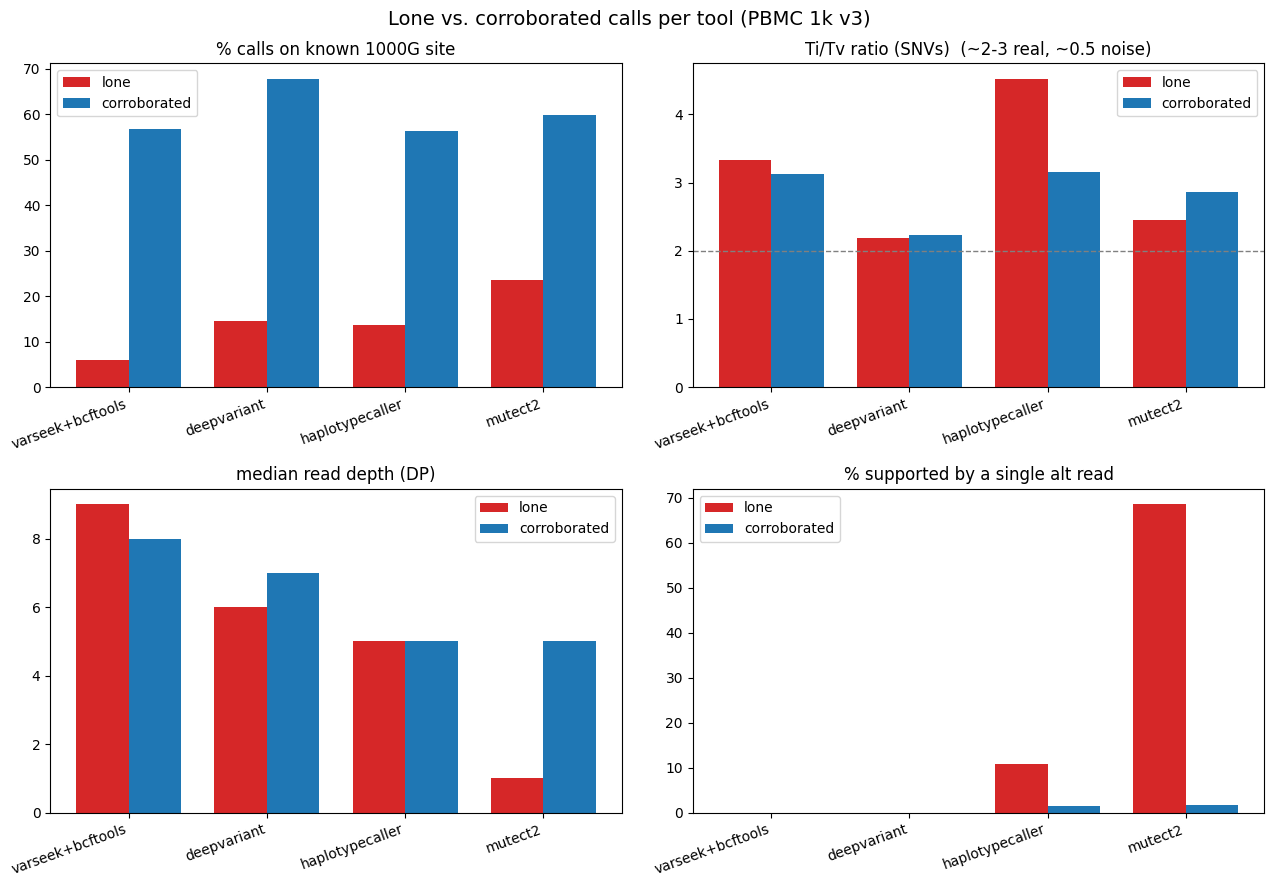


Lone calls stratified by read support:


,tool,support,n,% on 1000G site,Ti/Tv (SNVs)
0,varseek+bcftools,multi-read,111788,6.07,3.33
1,deepvariant,multi-read,34476,14.46,2.18
2,haplotypecaller,multi-read,21541,12.65,4.66
3,haplotypecaller,single-read,2624,21.95,3.84
4,mutect2,multi-read,29353,15.10,3.90
5,mutect2,single-read,63896,27.36,2.13


time: 978 ms (started: 2026-06-11 16:44:12 -07:00)


In [58]:
# ---------------------------------------------------------------------------
# Visual summary: lone vs corroborated per tool, one metric per panel; plus the
# within-lone "is the real signal where there is >1 read?" stratification.
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt

TOOLS = list(per_tool.keys())
COL = {"lone": "#d62728", "corroborated": "#1f77b4"}
x = np.arange(len(TOOLS)); width = 0.38

def _metric(metric, grp):
    return [lone_summary[(lone_summary.tool == t) & (lone_summary.group == grp)][metric].iloc[0]
            for t in TOOLS]

panels = [
    ("% on 1000G site",    "% calls on known 1000G site", None),
    ("Ti/Tv (SNVs)",       "Ti/Tv ratio (SNVs)  (~2-3 real, ~0.5 noise)", 2.0),
    ("median DP",          "median read depth (DP)", None),
    ("% single alt read",  "% supported by a single alt read", None),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (metric, title, hline) in zip(axes.ravel(), panels):
    ax.bar(x - width/2, _metric(metric, "lone"), width, label="lone", color=COL["lone"])
    ax.bar(x + width/2, _metric(metric, "corroborated"), width, label="corroborated", color=COL["corroborated"])
    if hline is not None:
        ax.axhline(hline, ls="--", c="gray", lw=1)
    ax.set_xticks(x); ax.set_xticklabels(TOOLS, rotation=20, ha="right")
    ax.set_title(title); ax.legend()
fig.suptitle("Lone vs. corroborated calls per tool (PBMC 1k v3)", fontsize=14)
fig.tight_layout()
lone_fig_path = os.path.join(happy_out, "lone_calls_by_tool.png")
fig.savefig(lone_fig_path, dpi=150, bbox_inches="tight")
print(f"Saved figure to {lone_fig_path}")
plt.show()

# Within each tool's lone set, split by read support: does germline overlap /
# Ti/Tv concentrate where there is more than one supporting read?
strat_rows = []
for tool, df in per_tool.items():
    ev = df[(df["group"] == "lone") & df["alt_AD"].notna()]
    if ev.empty:
        continue
    for label, sub in ev.groupby(np.where(ev["single_read"], "single-read", "multi-read")):
        ti, tv = int(sub["ti"].sum()), int(sub["tv"].sum())
        strat_rows.append({"tool": tool, "support": label, "n": len(sub),
                           "% on 1000G site": 100 * sub["in_1000G_site"].mean() if pos_hits is not None else np.nan,
                           "Ti/Tv (SNVs)": (ti / tv) if tv else np.nan})
print("\nLone calls stratified by read support:")
display(pd.DataFrame(strat_rows).round(2))


#### Takeaway

Running the Mutect2 assessment across every caller puts that result in context:
**every tool's lone calls are markedly worse-supported than its corroborated
calls, but they fail in tool-specific ways.**

The universal signal is germline overlap: lone calls sit on a known 1000 Genomes
site only ~6–24% of the time, versus ~56–68% for corroborated calls across all
four tools. Independent corroboration tracks real-variant status, exactly as
assumed. Where the tools differ is *why* their lone calls are suspect:

- **mutect2** — lone calls collapse to **single reads** (~69% rest on one alt
  read, median `DP` = 1). This is the most permissive caller, and its lone block
  is dominated by depth-1 calls the other tools' thresholds reject — a mix of
  low-coverage germline SNVs and sequencing/RT errors.
- **varseek + bcftools** — lone calls are, by contrast, **well-supported** (median
  `DP` ≈ 9, 0% single-read; `min_counts` ≥ 3 forbids single-read calls) yet have
  the **lowest** germline overlap (~6%) and a high Ti/Tv (~3.3). Good read support
  but non-germline and transition-heavy is the fingerprint of reproducible
  **RNA-level events** — A-to-I editing (A>G / T>C) and RT/mapping artifacts —
  real at the RNA level but not DNA variants, so absent from 1000 Genomes.
- **haplotypecaller** — lone calls are **42% indels** (vs ~14% when corroborated)
  with an inflated Ti/Tv (~4.5): its private block is enriched for indel/assembly
  artifacts.
- **deepvariant** — the most conservative (only ~16% of its calls are lone, and
  ~34% of those are indels); its lone Ti/Tv (~2.2) stays near the corroborated
  value, i.e. the least clearly-artifactual lone set of the four.

**Bottom line:** for no tool are the lone calls a clean pile of real variants the
others missed. Each tool's private set is dominated by its own characteristic
artifact mode — depth-1 noise (Mutect2), RNA-editing/RT signal (varseek+bcftools),
indel artifacts (HaplotypeCaller) — which is precisely why the *other* tools, with
different evidence models, don't reproduce them.

### Why does varseek miss ~15k variants that bcftools (and most callers) call?

In this notebook the **bcftools** track of the upset plot *is* varseek's own seed: `vk denovo` calls variants with bcftools and writes them to `variants.tsv`, which is then handed to `vk ref`. So every variant varseek lacks relative to bcftools is a seed variant that dropped out somewhere in the `vk ref` → `vk count` pipeline.

The quick check requested: how many seed variants are omitted from `vcrs.fa` (filtered in **vk build**) and from `vcrs_filtered.fa` (filtered in **vk filter**)? We trace each stage in HGVS space (`vk ref`'s native key, e.g. `1:g.199391G>A`) so every lost variant is attributed to the exact step that dropped it.

In [59]:
# ---------------------------------------------------------------------------
# Why does varseek "miss" ~15k variants that bcftools (and most callers) report?
# ---------------------------------------------------------------------------
# In this notebook the "bcftools" track of the upset plot IS varseek's own seed:
# vk denovo calls variants with bcftools and writes them to variants.tsv, which
# is then handed to vk ref. So every variant varseek lacks relative to bcftools
# is a *seed* variant that fell out somewhere in the vk ref -> vk count pipeline.
# We trace each stage in HGVS space (vk ref's native key, e.g. "1:g.199391G>A")
# so each lost variant is attributed to the exact step that dropped it:
#
#   seed (variants.tsv = bcftools calls)
#     -> vk build       -> vcrs.fa           (drop: cannot form a valid VCRS)
#     -> vk filter      -> vcrs_filtered.fa  (drop: low-complexity VCRS)
#     -> vk count/clean -> final calls       (drop: no pseudoalignment / below count threshold)
import os
import json
import pandas as pd

ref_dir = vk_ref_out_dir

# --- stage sets in HGVS space ------------------------------------------------
seed_df = pd.read_csv(variants, sep="\t", dtype=str)
seed_set = set(seed_df["seq_id"] + ":" + seed_df["variant"])


def _header_set(csv_path):
    # id_to_header_mapping files map one VCRS id -> one (possibly ";"-merged)
    # header. Explode so the unit of comparison is a single variant.
    s = pd.read_csv(csv_path, dtype=str)["vcrs_header"]
    return set(s.str.split(";").explode())


build_set = _header_set(os.path.join(ref_dir, "id_to_header_mapping.csv"))           # survived vk build  -> vcrs.fa
filter_set = _header_set(os.path.join(ref_dir, "id_to_header_mapping_filtered.csv"))  # survived vk filter -> vcrs_filtered.fa

# Final varseek calls (after vk count + vk clean): variants supported in >=1 cell,
# matching how the "varseek" upset track is built earlier in the notebook.
final_set = None
adata_path = os.path.join(vk_count_out_dir, "adata_cleaned.h5ad")
try:
    _adata = ad.read_h5ad(adata_path)
    _kept = _adata[:, _adata.X.sum(axis=0) > 0].var_names.tolist()
    final_set = set(pd.Series(_kept, dtype="object").str.split(";").explode())
    del _adata
except Exception as e:  # noqa: BLE001
    print(f"(skipping final count/clean stage; could not read {adata_path}: {e})")

# --- per-stage drops ---------------------------------------------------------
dropped_build = seed_set - build_set      # in seed, not in vcrs.fa
dropped_filter = build_set - filter_set   # in vcrs.fa, not in vcrs_filtered.fa
dropped_count = (filter_set - final_set) if final_set is not None else set()

funnel = [
    ("seed = bcftools / vk denovo calls",       len(seed_set),   None),
    ("survived vk build  (in vcrs.fa)",          len(build_set),  len(dropped_build)),
    ("survived vk filter (in vcrs_filtered.fa)", len(filter_set), len(dropped_filter)),
]
if final_set is not None:
    funnel.append(("final varseek calls (post count/clean)", len(final_set), len(dropped_count)))

print("variant funnel (HGVS-level, single-variant units)")
print("-" * 70)
for label, kept, dropped in funnel:
    drop_str = "" if dropped is None else f"   (-{dropped:,} dropped here)"
    print(f"{kept:>9,}  {label}{drop_str}")
print("-" * 70)
print(f"{len(seed_set - filter_set):>9,}  dropped by vk build + vk filter combined")
if final_set is not None:
    print(f"{len(seed_set - final_set):>9,}  total bcftools/seed calls that varseek does NOT report")


variant funnel (HGVS-level, single-variant units)
----------------------------------------------------------------------
  325,583  seed = bcftools / vk denovo calls
  325,358  survived vk build  (in vcrs.fa)   (-432 dropped here)
  310,986  survived vk filter (in vcrs_filtered.fa)   (-14,372 dropped here)
  230,826  final varseek calls (post count/clean)   (-80,160 dropped here)
----------------------------------------------------------------------
   14,790  dropped by vk build + vk filter combined
   94,903  total bcftools/seed calls that varseek does NOT report
time: 6.57 s (started: 2026-06-11 16:44:13 -07:00)


VCRSs entering vk filter : 324,999
VCRSs dropped by vk filter: 14,325 (4.4% of post-build VCRSs)
keep-rules: ['alignment_to_reference:is_not_true', 'pseudoaligned_to_reference_despite_not_truly_aligning:is_not_true', 'num_distinct_triplets:greater_than=5', 'longest_homopolymer_length:less_or_equal=10']
       22  VCRSs fail  num_distinct_triplets greater_than 5
   14,304  VCRSs fail  longest_homopolymer_length less_or_equal 10
        -  'alignment_to_reference:is_not_true' evaluated during vk filter (d-list/genome alignment); removed no extra VCRS here
        -  'pseudoaligned_to_reference_despite_not_truly_aligning:is_not_true' evaluated during vk filter (d-list/genome alignment); removed no extra VCRS here

Saved data/happy_output/varseek_dropout_funnel.png


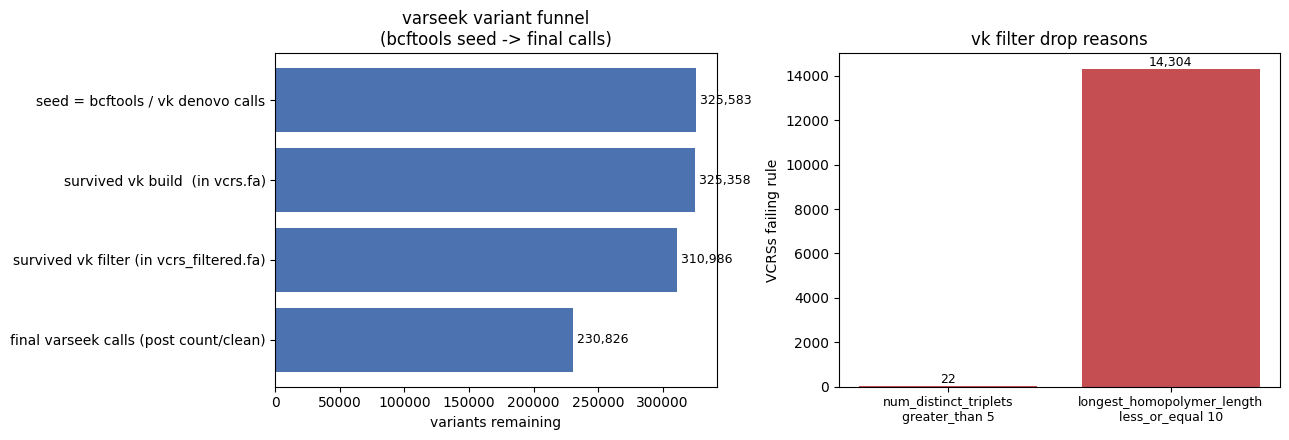

time: 860 ms (started: 2026-06-11 16:44:20 -07:00)


In [60]:
# ---------------------------------------------------------------------------
# vk filter is the dominant *reference-construction* cause -- break it down by rule
# ---------------------------------------------------------------------------
# vk filter keeps a VCRS only if it passes EVERY rule in vk_filter_config.json.
# The rule metrics live in variants_updated_vk_info.csv (one row per post-build
# VCRS), so we can attribute each dropped VCRS to the rule(s) it fails. Two of the
# rules ("...:is_not_true") are d-list / genome-alignment checks computed during
# vk filter itself (see bowtie_vcrs_kmers_to_genome/) and are not columns in the
# info table; in this run the two sequence-complexity rules already account for
# the entire VCRS drop (matches filtering_report.txt), so they are the story.
import matplotlib.pyplot as plt

with open(os.path.join(ref_dir, "config", "vk_filter_config.json")) as fh:
    filter_rules = json.load(fh)["filters"]

_ops = {  # each returns True where the VCRS PASSES (keeps) the rule
    "greater_than":     lambda s, v: s >  v,
    "greater_or_equal": lambda s, v: s >= v,
    "less_than":        lambda s, v: s <  v,
    "less_or_equal":    lambda s, v: s <= v,
    "equal":            lambda s, v: s == v,
    "is_true":          lambda s, v: s.astype(bool),
    "is_not_true":      lambda s, v: ~s.astype(bool),
    "is_false":         lambda s, v: ~s.astype(bool),
    "is_not_false":     lambda s, v: s.astype(bool),
}

parsed = []
for rule in filter_rules:                 # "longest_homopolymer_length:less_or_equal=10" or "x:is_not_true"
    col, rest = rule.split(":", 1)
    op, _, val = rest.partition("=")
    parsed.append((col, op, float(val) if val else None))

available = set(pd.read_csv(os.path.join(ref_dir, "variants_updated_vk_info.csv"), nrows=0).columns)
eval_cols = [c for c, _, _ in parsed if c in available]
skipped = [(c, op) for c, op, _ in parsed if c not in available]

info = pd.read_csv(
    os.path.join(ref_dir, "variants_updated_vk_info.csv"),
    usecols=["vcrs_header", *eval_cols],
)

# Each VCRS is kept iff it passes every keep-rule; it is dropped if it fails any.
fail_counts = {}
drop_any = pd.Series(False, index=info.index)
for col, op, val in parsed:
    if col not in available:
        continue
    failed = ~_ops[op](info[col], val)             # True => violates this keep-rule
    fail_counts[f"{col}\n{op} {val:g}"] = int(failed.sum())
    drop_any |= failed

print(f"VCRSs entering vk filter : {len(info):,}")
print(f"VCRSs dropped by vk filter: {int(drop_any.sum()):,} "
      f"({100 * drop_any.mean():.1f}% of post-build VCRSs)")
print("keep-rules:", filter_rules)
for k, v in fail_counts.items():
    a, b = k.splitlines()
    print(f"  {v:>7,}  VCRSs fail  {a} {b}")
for c, op in skipped:
    print(f"        -  '{c}:{op}' evaluated during vk filter (d-list/genome alignment); "
          f"removed no extra VCRS here")

# --- visual summary: funnel + filter drop reasons ----------------------------
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.5))

labels = [f[0] for f in funnel]
counts = [f[1] for f in funnel]
axL.barh(range(len(counts)), counts, color="#4C72B0")
axL.set_yticks(range(len(counts)))
axL.set_yticklabels(labels)
axL.invert_yaxis()
for i, c in enumerate(counts):
    axL.text(c, i, f" {c:,}", va="center", fontsize=9)
axL.set_xlabel("variants remaining")
axL.set_title("varseek variant funnel\n(bcftools seed -> final calls)")

rlabels = list(fail_counts.keys())
rvals = list(fail_counts.values())
axR.bar(range(len(rvals)), rvals, color="#C44E52")
axR.set_xticks(range(len(rvals)))
axR.set_xticklabels(rlabels, rotation=0, ha="center", fontsize=9)
for i, v in enumerate(rvals):
    axR.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
axR.set_ylabel("VCRSs failing rule")
axR.set_title("vk filter drop reasons")

fig.tight_layout()
out_png = os.path.join(happy_out, "varseek_dropout_funnel.png")
os.makedirs(happy_out, exist_ok=True)
fig.savefig(out_png, dpi=150, bbox_inches="tight")
print(f"\nSaved {out_png}")
plt.show()


#### Takeaway

The seed → final funnel localizes the loss precisely:

- **`vk build` drops almost nothing** — ~225–432 seed variants (<0.15%). These are variants that can't form a valid VCRS (too close to a contig end, ambiguous bases with `max_ambiguous=0`, or indels that re-represent under HGVS normalization). Negligible.
- **`vk filter` is the dominant reference-construction filter — 14,372 variants (14,325 VCRSs, 4.4%)**, and this is almost entirely **one rule**: `longest_homopolymer_length <= 10` removes **14,304 VCRSs**. The complexity rule `num_distinct_triplets > 5` removes only 22 more, and the two d-list/genome-alignment rules remove none beyond those. So varseek deliberately discards VCRSs whose sequence is dominated by a long homopolymer run — those k-mers pseudoalign promiscuously and would generate unreliable counts.
- **`vk build` + `vk filter` together remove 14,790 seed variants** — squarely the "~15–20k" the question asks about, and the same order as the high-confidence (multi-caller-corroborated) calls varseek lacks in the upset plot.

For completeness the funnel also shows `vk count`/`vk clean` drops a much larger ~80k, but those are a different population: overwhelmingly bcftools-*private* low-coverage de novo calls that no other caller corroborates and that fail pseudoalignment or the count threshold — not the multi-caller consensus variants this question is about. See also [[varseek-misses-minus-strand-variants]] for the strand-mismatch contribution at the count stage.

The single highest-leverage knob if recovering these matters: relax `longest_homopolymer_length` in the `vk filter`/`vk ref` `filters` list.

## COSMIC comparison

In [5]:
# vk ref out
vk_ref_out_dir = os.path.join("data", "varseek_ref_out_pbmc_1k_v3_cosmic")
vcrs_index = os.path.join(vk_ref_out_dir, "vcrs_index_denovo.idx")
vcrs_t2g = os.path.join(vk_ref_out_dir, "vcrs_t2g_denovo.txt")

# vk count out
vk_count_out_dir = os.path.join("data", "varseek_count_out_pbmc_1k_v3_cosmic")
vk_count_variants_vcf_cosmic = os.path.join(vk_count_out_dir, "varseek_variants.vcf")

time: 529 μs (started: 2026-06-15 08:18:30 -07:00)


In [18]:
cosmic_tsv = "data/cosmic/Cosmic_MutantCensus_v104_GRCh38.tsv"

if not os.path.exists(cosmic_tsv):
    raise FileNotFoundError(f"Cosmic TSV not found at {cosmic_tsv}; please download from https://cancer.sanger.ac.uk/cosmic/download/cosmic/v104/mutantcensus.")

cosmic_tsv_cols = pd.read_csv(cosmic_tsv, sep="\t", nrows=0).columns
if "seq_id" not in cosmic_tsv_cols or "variant" not in cosmic_tsv_cols:
    cosmic_df = pd.read_csv(cosmic_tsv, sep="\t")
    cosmic_df[["seq_id", "variant"]] = cosmic_df["HGVSG"].str.split(":", n=1, expand=True)
    cosmic_df.to_csv(cosmic_tsv, sep="\t", index=False)

time: 53.5 ms (started: 2026-06-12 12:43:05 -07:00)


In [ ]:
if not os.path.exists(vcrs_index):
    vk_ref_output_dict = vk.ref(
        variants=cosmic_tsv,
        sequences=sequences,
        seq_id_column="seq_id",
        var_column="variant",
        out=vk_ref_out_dir,
        reference_out_dir=reference_dir,
        dlist_reference_source="t2t",
        index_out=vcrs_index,
        t2g_out=vcrs_t2g,
        w=w,
        k=k
    )

12:43:08 - INFO - Using COSMIC email from COSMIC_EMAIL environment variable
12:43:08 - INFO - Using COSMIC password from COSMIC_PASSWORD environment variable
12:43:08 - INFO - Running vk build
12:43:08 - INFO - Using COSMIC email from COSMIC_EMAIL environment variable: jmrich@caltech.edu
12:43:08 - INFO - Using COSMIC password from COSMIC_PASSWORD environment variable
/home/jrich/Desktop/varseek/varseek/varseek_build.py:781: DtypeWarning: Columns (14,26) have mixed types. Specify dtype option on import or set low_memory=False.
  mutations = pd.read_csv(mutations, sep="\t")
12:44:13 - INFO - Using the seq_id_column:var_column 'seq_id:variant' columns as the variant header column.
12:44:42 - INFO - Removing 110 duplications > k
/home/jrich/Desktop/varseek/varseek/varseek_build.py:1252: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyd

Swapping complete


12:51:42 - INFO - About to apply safe evals
12:51:48 - WARNING - Some headers do not follow the HGVS pattern. Please check the input data.
12:52:30 - INFO - Collapsing dataframe
13:06:12 - INFO - Aligning to normal genome and building dlist
13:06:12 - INFO - Running bowtie2 alignment
13:06:12 - ERROR - Error aligning to normal genome and building alignment_to_reference: Command '['bowtie2', '-a', '-f', '-p', '2', '--xeq', '--score-min', 'C,0,0', '--np', '1', '--n-ceil', 'C,0,0', '-F', '41,1', '-R', '1', '-N', '0', '-L', '31', '-i', 'C,1,0', '--no-1mm-upfront', '--no-unal', '--no-hd', '-x', 'data/reference/t2t/bowtie_index_genome/data/reference/t2t/bowtie_index_genome/index', '-U', 'data/varseek_ref_out_pbmc_1k_v3_cosmic/vcrs.fa', '-S', 'data/varseek_ref_out_pbmc_1k_v3_cosmic/bowtie_vcrs_kmers_to_genome/alignment.sam']' returned non-zero exit status 2.
13:06:12 - WARNING - alignment_to_reference not found in dataframe. Skipping pseudoalignment to reference.
13:06:12 - INFO - Calculating

time: 26min 4s (started: 2026-06-12 12:43:08 -07:00)


In [6]:
vk_count_output_dict = vk.count(
    fastqs_dir,
    index=vcrs_index,
    t2g=vcrs_t2g,
    technology=technology,
    out=vk_count_out_dir,
    k=k,
    threads=threads,
    strand="unstranded",
    min_counts=min_counts_clean,
)

08:18:44 - INFO - Removing index files from fastq files list, as they are not utilized in kb count with technology 10XV3
08:18:44 - INFO - File data/pbmc_1k_v3_fastqs/combined_R2.fastq.gz does not match the Illumina file naming convention of SAMPLE_LANE_R[12]_001.fastq.gz, so removing it from the fastq files list.
08:18:44 - INFO - Setting length_required to 41 if fastqpp is run
08:18:44 - INFO - Skipping vk fastqpp because there was no use for it
08:18:44 - INFO - Running kb count with command: kb count -t 16 -k 41 -i data/varseek_ref_out_pbmc_1k_v3_cosmic/vcrs_index_denovo.idx -g data/varseek_ref_out_pbmc_1k_v3_cosmic/vcrs_t2g_denovo.txt -x 10XV3 --h5ad -o data/varseek_count_out_pbmc_1k_v3_cosmic/kb_count_out_vcrs --overwrite --strand unstranded --num --mm --union data/pbmc_1k_v3_fastqs/pbmc_1k_v3_S1_L001_R1_001.fastq.gz data/pbmc_1k_v3_fastqs/pbmc_1k_v3_S1_L001_R2_001.fastq.gz data/pbmc_1k_v3_fastqs/pbmc_1k_v3_S1_L002_R1_001.fastq.gz data/pbmc_1k_v3_fastqs/pbmc_1k_v3_S1_L002_R2_001.

time: 5min 13s (started: 2026-06-15 08:18:44 -07:00)


In [9]:
adata_path = vk_count_output_dict['adata_path']  #  if not use_unfiltered_varseek else vk_count_output_dict['adata_path_unprocessed']
adata_to_vcf(adata_path, vk_count_variants_vcf_cosmic)

Could not parse: 7:g.27959750dup
Could not parse: 7:g.28034494_28034503dup
Could not parse: 7:g.28118789_28118792dup
Could not parse: 7:g.28134727dup
Could not parse: 8:g.108060290dup
Could not parse: 8:g.108035644dup
Could not parse: 8:g.108062539_108062542dup
Could not parse: 7:g.27988697dup
Could not parse: 7:g.27985022dup
Could not parse: 17:g.17212311dup
Could not parse: 3:g.185392894dup
Could not parse: 3:g.53628027dup
Could not parse: 3:g.185432460dup
Could not parse: 17:g.49824540dup
Could not parse: 9:g.95203240dup
Could not parse: 9:g.95301201_95301206dup
Could not parse: 9:g.95301205_95301206dup
Could not parse: 9:g.95238583dup
Could not parse: 9:g.95257591dup
Could not parse: 10:g.32037694_32037695delinsAT
Could not parse: 10:g.32037725_32037726inv
Could not parse: 4:g.53453093_53453094dup
Could not parse: 4:g.53453030_53453031dup
Could not parse: 5:g.159087353_159087354dup
Could not parse: X:g.119633440dup
Could not parse: 19:g.14091929dup
Could not parse: 11:g.3737477dup


In [13]:
happy_out = os.path.join("data", "happy_output_cosmic")
label = "varseek_cosmic"
# if not use_unfiltered_varseek:
#     happy_out += "_filtered"

compare_with_happy(
    varseek_vcf=vk_count_variants_vcf,
    alternate_vcf=vk_count_variants_vcf_cosmic,
    reference_fasta=sequences,
    output_dir=happy_out,
    output_prefix=f"varseek_vs_{label}"
)

Writing to /home/jrich/tmp/bcftools.eeJTCl
Lines   total/split/joined/realigned/removed/skipped:	48463/0/0/1525/0/0
Merging 1 temporary files
Done
Cleaning


Normalized file /home/jrich/Desktop/varseek-examples/data/varseek_count_out_pbmc_1k_v3/varseek_variants_normalized.vcf already exists. Skipping normalization.


2026-06-15 15:27:58,787 WARNING  No reference file found at default locations. You can set the environment variable 'HGREF' or 'HG19' to point to a suitable Fasta file.
[W] overlapping records at 12:66227605 for sample 0
[W] Variants that overlap on the reference allele: 10
[I] Total VCF records:         230680
[I] Non-reference VCF records: 230680
[W] overlapping records at 1:204557929 for sample 0
[W] Variants that overlap on the reference allele: 65
[I] Total VCF records:         48463
[I] Non-reference VCF records: 48463
2026-06-15 15:28:02,687 WARNING  No calls for location MT in query!
2026-06-15 15:28:02,688 WARNING  No calls for location Y in query!


Hap.py v0.3.12
Benchmarking Summary:
Type Filter  TRUTH.TOTAL  TRUTH.TP  TRUTH.FN  QUERY.TOTAL  QUERY.FP  QUERY.UNK  FP.gt  FP.al  METRIC.Recall  METRIC.Precision  METRIC.Frac_NA  METRIC.F1_Score  TRUTH.TOTAL.TiTv_ratio  QUERY.TOTAL.TiTv_ratio  TRUTH.TOTAL.het_hom_ratio  QUERY.TOTAL.het_hom_ratio
INDEL    ALL        16331        65     16266         2034      1968          0      0      0        0.00398          0.032448             0.0         0.007091                     NaN                     NaN                        NaN                        NaN
INDEL   PASS        16331        65     16266         2034      1968          0      0      0        0.00398          0.032448             0.0         0.007091                     NaN                     NaN                        NaN                        NaN
  SNP    ALL       214349      1001    213348        46429     45429          0      0      0        0.00467          0.021538             0.0         0.007676                3.6

In [14]:
# Collect the hap.py summary tables into one view.
# varseek is the TRUTH set and each caller is the QUERY, so:
#   Recall    = fraction of varseek calls confirmed by the caller
#   Precision = fraction of the caller's calls also in varseek (low by design:
#               varseek reports a small targeted subset vs. a genome-wide caller)
summary_frames = []
for label, alternate_vcf in [("varseek_cosmic", vk_count_variants_vcf_cosmic)]:
    summary_csv_path = os.path.join(happy_out, f"varseek_vs_{label}.summary.csv")
    if not os.path.isfile(summary_csv_path):
        continue
    df = pd.read_csv(summary_csv_path)
    df.insert(0, "Caller", label)
    summary_frames.append(df)

if summary_frames:
    summary_all = pd.concat(summary_frames, ignore_index=True)
    cols = ["Caller", "Type", "Filter", "TRUTH.TOTAL", "TRUTH.TP", "TRUTH.FN",
            "QUERY.TOTAL", "QUERY.FP", "METRIC.Recall", "METRIC.Precision", "METRIC.F1_Score"]
    display(summary_all[cols])
else:
    print("No hap.py summaries found yet -- run the comparison cell above first.")


,Caller,Type,Filter,TRUTH.TOTAL,TRUTH.TP,TRUTH.FN,QUERY.TOTAL,QUERY.FP,METRIC.Recall,METRIC.Precision,METRIC.F1_Score
0,varseek_cosmic,INDEL,ALL,16331,65,16266,2034,1968,0.00398,0.032448,0.007091
1,varseek_cosmic,INDEL,PASS,16331,65,16266,2034,1968,0.00398,0.032448,0.007091
2,varseek_cosmic,SNP,ALL,214349,1001,213348,46429,45429,0.00467,0.021538,0.007676
3,varseek_cosmic,SNP,PASS,214349,1001,213348,46429,45429,0.00467,0.021538,0.007676


time: 15.3 ms (started: 2026-06-15 08:31:21 -07:00)


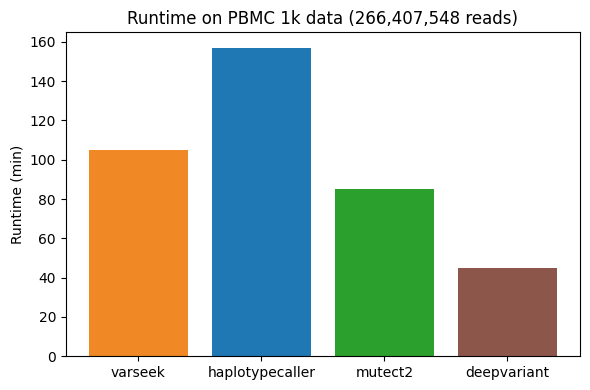

In [1]:
runtimes = {
	"varseek": 105,
	"haplotypecaller": 157,
	"mutect2": 85,
	"deepvariant": 45,
}
#* STAR is 5-10min

import matplotlib.pyplot as plt
color_map_20 = ["#f08925", "#1f77b4", "#2ca02c", "#8c564b",  "#d62728", "#9467bd", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", "#aec7e8", "#ffbb78", "#98df8a", "#ff9896", "#c5b0d5", "#c49c94", "#f7b6d2", "#c7c7c7", "#dbdb8d", "#9edae5"]

plt.figure(figsize=(6, 4))
plt.bar(runtimes.keys(), runtimes.values(), color=color_map_20[:len(runtimes)])
plt.ylabel("Runtime (min)")
plt.title("Runtime on PBMC 1k data (266,407,548 reads)")
plt.tight_layout()
plt.show()